# Experiment 3 GRU-D Observation-Frequency Shift

This notebook mirrors the LSTM Experiment 3 visualizer for GRU-D runs only. It keeps the existing Exp3A r=8 analysis and adds support for the GRU-D Exp3A r=4, Exp3B normalizer control, Exp3C random-matched shift, and Exp3D h=96 replication runs while experiments are still partially complete.

Positive contrast values always mean the left/matched condition performs better. For Brier score, the notebook reports `mismatched - matched`, so positive means the matched condition has lower/better Brier.

In [1]:
EXP3_GRUD_ALLOW_PARTIAL_RESULTS = True
EXP3_GRUD_REQUIRE_COMPLETE_EPOCHS = False
# Missing test predictions are generated automatically.
# Set this to True only when intentionally regenerating ALL GRU-D test predictions in this notebook.
RERUN_ALL_TEST_INFERENCE = False

## Configuration

GRU-D-specific fields are adapted from the LSTM Experiment 3 notebook: `k_grud` filenames, `mimic4models/keras_models/grud.py`, depth 1, and GRU-D run directories. Experiment definitions, contrast orientation, checkpoint selection, prediction naming, and uncertainty calculations follow the LSTM Exp3 notebook.

In [2]:
from pathlib import Path
import os
import re
import shlex
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t

from visualize_utils import (
    DEFAULT_BOOTSTRAP_SEED,
    across_seed_patient_bootstrap,
    find_selected_checkpoint,
    load_prediction_csv,
    metric_difference,
    paired_patient_bootstrap,
    paired_prediction_frame,
    prediction_metrics,
    read_validation_log,
    show_table,
    summarize_with_t_ci,
)

PROJECT_DATA_ROOT = Path(os.environ.get(
    "PROJECT_DATA_ROOT",
    "/heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo",
))
EXP3_GRUD_REPO_DIR = Path.cwd().parent if Path.cwd().name == "visualizers" else Path.cwd()
EXP3_GRUD_PYTHON = os.environ.get("EXP3_GRUD_PYTHON", os.environ.get("EXP3_PYTHON", "python"))
EXP3_GRUD_DATA_DIR = PROJECT_DATA_ROOT / "data/length-of-stay"
EXP3_GRUD_NORMALIZER_DIR = PROJECT_DATA_ROOT / "normalizers"
EXP3_GRUD_RESULTS_DIR = PROJECT_DATA_ROOT / "results/fixed_horizon_icu_exit"
EXP3_GRUD_OUTPUT_DIR = EXP3_GRUD_RESULTS_DIR / "plots"
EXP3_GRUD_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

EXP3_GRUD_NETWORK = "mimic4models/keras_models/grud.py"
EXP3_GRUD_FILENAME_PREFIX = "k_grud"
EXP3_GRUD_HORIZONS = [12, 96]
EXP3_GRUD_STRUCTURED_CONFIGS = {12: [4, 8], 96: [4]}
EXP3_GRUD_RANDOM_MATCHED_CONFIGS = {12: [4]}
EXP3_GRUD_NORMALIZER_CONTROL_CONFIGS = {12: [4]}
EXP3_GRUD_RANDOM_MATCHED_SAMPLING_SEED = 100
EXP3_GRUD_EXPECTED_MODEL_SEEDS = {0, 1, 2, 3, 4}
EXP3_GRUD_EXPECTED_EPOCHS = 100
EXP3_GRUD_TIMESTEP = 1.0
EXP3_GRUD_METRICS = ["auprc", "auroc", "brier"]
EXP3_GRUD_N_BOOT = int(os.environ.get("EXP3_GRUD_N_BOOT", os.environ.get("EXP3_N_BOOT", "2000")))
EXP3_GRUD_BOOTSTRAP_SEED = DEFAULT_BOOTSTRAP_SEED

EXP3_GRUD_EXPECTED_CONFIG = {
    "network": EXP3_GRUD_NETWORK,
    "dim": 16,
    "depth": 1,
    "dropout": 0.3,
    "rec_dropout": 0.0,
    "batch_norm": False,
    "batch_size": 8,
    "timestep": EXP3_GRUD_TIMESTEP,
    "target_repl_coef": 0.0,
    "l1": 0.0,
    "l2": 0.0,
    "optimizer": "adam",
    "lr": 0.001,
    "beta_1": 0.9,
    "imputation": "previous",
    "prefix": "",
}

EXP3_GRUD_MAIN_CONTRASTS = [
    ("Exp3A Structured frequency shift", 12, 4, "structured shift"),
    ("Exp3A Structured frequency shift", 12, 8, "structured shift"),
    ("Exp3C Random-matched frequency shift", 12, 4, "random-matched shift"),
    ("Exp3D Horizon replication", 96, 4, "structured shift"),
]

print("GRU-D result root:", EXP3_GRUD_RESULTS_DIR)
print("Structured configs:", EXP3_GRUD_STRUCTURED_CONFIGS)
print("Random-matched configs:", EXP3_GRUD_RANDOM_MATCHED_CONFIGS)
print("Normalizer-control configs:", EXP3_GRUD_NORMALIZER_CONTROL_CONFIGS)
print("Random-matched sampling seed:", EXP3_GRUD_RANDOM_MATCHED_SAMPLING_SEED)
print("Expected model seeds:", sorted(EXP3_GRUD_EXPECTED_MODEL_SEEDS))
print("Bootstrap draws:", EXP3_GRUD_N_BOOT)
print("Partial final summaries allowed:", EXP3_GRUD_ALLOW_PARTIAL_RESULTS)
print("Missing test predictions: AUTO-RUN")
print("Rerun all existing test predictions:", RERUN_ALL_TEST_INFERENCE)
if RERUN_ALL_TEST_INFERENCE:
    print("WARNING: ALL eligible GRU-D test predictions in this notebook will be regenerated.")

GRU-D result root: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit
Structured configs: {12: [4, 8], 96: [4]}
Random-matched configs: {12: [4]}
Normalizer-control configs: {12: [4]}
Random-matched sampling seed: 100
Expected model seeds: [0, 1, 2, 3, 4]
Bootstrap draws: 2000
Partial final summaries allowed: True
Missing test predictions: AUTO-RUN
Rerun all existing test predictions: False


## Shared GRU-D Helpers

The provenance chain is strict:

`validation log -> validation-AUPRC selected CSV epoch -> checkpoint epoch = CSV epoch + 1 -> exact checkpoint path -> exact expected prediction path`

Prediction filenames use the same convention as `mimic4models.fixed_horizon_icu_exit.main`: matched train/test regimes use `<checkpoint>.csv`; shifted test regimes use `<checkpoint>.testsample-...csv`.

In [3]:
def _search(pattern, text, cast=None, default=None):
    m = re.search(pattern, text)
    if m is None:
        return default
    value = m.group(1)
    return cast(value) if cast is not None else value


def parse_sampling_from_name(name):
    sample = re.search(
        r"\.sample(?P<strategy>structured|random_matched)"
        r"\.r(?P<interval>\d+)"
        r"(?:\.sseed(?P<sseed>\d+))?",
        name,
    )
    if sample is None:
        return "none", None, None
    strategy = sample.group("strategy")
    interval = int(sample.group("interval"))
    seed = sample.group("sseed")
    return strategy, interval, int(seed) if seed is not None else None


def parse_grud_log_name(log_path, run_kind, normalizer_regime):
    name = log_path.name
    if not name.startswith(EXP3_GRUD_FILENAME_PREFIX):
        raise ValueError("Not a GRU-D log filename: {}".format(name))
    strategy, interval, sampling_seed = parse_sampling_from_name(name)
    l1 = _search(r"\.L1([0-9.eE+-]+)(?=\.|$)", name, float, 0.0)
    l2 = _search(r"\.L2([0-9.eE+-]+)(?=\.|$)", name, float, 0.0)
    return {
        "model": "GRU-D",
        "filename": name,
        "run_kind": run_kind,
        "normalizer_regime": normalizer_regime,
        "horizon": _search(r"\.h(\d+)", name, int),
        "timestep": _search(r"\.ts([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float),
        "model_seed": _search(r"\.seed(\d+)(?:\.|$)", name, int),
        "train_sampling_strategy": strategy,
        "train_sampling_interval": interval,
        "train_sampling_seed": sampling_seed,
        "dim": _search(r"\.n(\d+)", name, int),
        "dropout": _search(r"\.d([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float, 0.0),
        "rec_dropout": _search(r"\.rd([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float, 0.0),
        "batch_norm": re.search(r"\.bn(?=\.|$)", name) is not None,
        "depth": _search(r"\.dep(\d+)", name, int),
        "batch_size": _search(r"\.bs(\d+)", name, int),
        "target_repl_coef": _search(r"\.trc([0-9]+(?:\.[0-9]+)?)(?=\.|$)", name, float, 0.0),
        "l1": l1,
        "l2": l2,
        "log_path": str(log_path),
        "output_dir": str(log_path.parent.parent),
        "network": EXP3_GRUD_NETWORK,
        "optimizer": EXP3_GRUD_EXPECTED_CONFIG["optimizer"],
        "lr": EXP3_GRUD_EXPECTED_CONFIG["lr"],
        "beta_1": EXP3_GRUD_EXPECTED_CONFIG["beta_1"],
        "imputation": EXP3_GRUD_EXPECTED_CONFIG["imputation"],
        "prefix": EXP3_GRUD_EXPECTED_CONFIG["prefix"],
    }


def _float_mismatch(actual, expected, tol=1e-9):
    if actual is None:
        return True
    return abs(float(actual) - float(expected)) > tol


def grud_hyperparameter_mismatch_reason(run):
    reasons = []
    for key in ["dim", "depth", "batch_size"]:
        if run.get(key) != EXP3_GRUD_EXPECTED_CONFIG[key]:
            reasons.append("{}={} expected {}".format(key, run.get(key), EXP3_GRUD_EXPECTED_CONFIG[key]))
    for key in ["dropout", "rec_dropout", "target_repl_coef", "l1", "l2", "timestep"]:
        if _float_mismatch(run.get(key), EXP3_GRUD_EXPECTED_CONFIG[key]):
            reasons.append("{}={} expected {}".format(key, run.get(key), EXP3_GRUD_EXPECTED_CONFIG[key]))
    if run.get("horizon") not in EXP3_GRUD_HORIZONS:
        reasons.append("horizon={} not in expected {}".format(run.get("horizon"), EXP3_GRUD_HORIZONS))
    if bool(run.get("batch_norm")) != bool(EXP3_GRUD_EXPECTED_CONFIG["batch_norm"]):
        reasons.append("batch_norm={} expected {}".format(run.get("batch_norm"), EXP3_GRUD_EXPECTED_CONFIG["batch_norm"]))
    if run.get("model_seed") not in EXP3_GRUD_EXPECTED_MODEL_SEEDS:
        reasons.append("model_seed={} not in expected {}".format(run.get("model_seed"), sorted(EXP3_GRUD_EXPECTED_MODEL_SEEDS)))
    return "; ".join(reasons)


def effective_sampling_regime(strategy, interval, seed):
    if strategy == "none":
        return ("none",)
    if strategy == "structured":
        return ("structured", int(interval))
    if strategy == "random_matched":
        return ("random_matched", int(interval), seed)
    raise ValueError("Unknown sampling strategy {}".format(strategy))


def regimes_match(train_strategy, train_interval, train_seed, test_strategy, test_interval, test_seed):
    return effective_sampling_regime(train_strategy, train_interval, train_seed) == effective_sampling_regime(
        test_strategy, test_interval, test_seed)


def sampling_label(strategy, interval, seed=None):
    if strategy == "none":
        return "dense"
    if strategy == "structured":
        return "structured-r{}".format(int(interval))
    if strategy == "random_matched":
        label = "random-r{}".format(int(interval))
        if seed is not None and not pd.isnull(seed):
            label += "-sseed{}".format(int(seed))
        return label
    raise ValueError("Unknown sampling strategy {}".format(strategy))


def regime_label(train_strategy, train_interval, train_seed, test_strategy, test_interval, test_seed):
    return "{}->{}".format(
        sampling_label(train_strategy, train_interval, train_seed),
        sampling_label(test_strategy, test_interval, test_seed),
    )


def test_sampling_suffix(strategy, interval, seed):
    if strategy == "none":
        return "testsample-none"
    label = "testsample-{}-r{}".format(strategy, int(interval))
    if strategy == "random_matched":
        label += "-sseed{}".format(int(seed))
    return label


def expected_prediction_path(output_dir, checkpoint, train_strategy, train_interval, train_seed,
                             test_strategy, test_interval, test_seed):
    pred_dir = Path(output_dir) / "test_predictions"
    base = pred_dir / checkpoint.name
    if regimes_match(train_strategy, train_interval, train_seed, test_strategy, test_interval, test_seed):
        return Path(str(base) + ".csv")
    return Path(str(base) + ".{}.csv".format(test_sampling_suffix(test_strategy, test_interval, test_seed)))


def parse_prediction_test_regime(prediction_path, checkpoint, train_strategy, train_interval, train_seed):
    name = Path(prediction_path).name
    matched_name = checkpoint.name + ".csv"
    if name == matched_name:
        return train_strategy, train_interval, train_seed, "matched-original-filename"
    prefix = checkpoint.name + ".testsample-"
    if not (name.startswith(prefix) and name.endswith(".csv")):
        raise ValueError("Prediction file does not match checkpoint naming convention: {}".format(prediction_path))
    label = name[len(prefix):-4]
    if label == "none":
        return "none", None, None, "explicit-testsample-suffix"
    m = re.match(r"(?P<strategy>structured|random_matched)-r(?P<interval>\d+)(?:-sseed(?P<seed>\d+))?$", label)
    if m is None:
        raise ValueError("Unrecognized test-sampling suffix in {}".format(prediction_path))
    strategy = m.group("strategy")
    interval = int(m.group("interval"))
    seed = m.group("seed")
    return strategy, interval, int(seed) if seed is not None else None, "explicit-testsample-suffix"

In [4]:
def normalizer_candidates_for_regime(strategy, interval, seed):
    if strategy == "none":
        pattern = "fixed_horizon_icu_exit_ts:{:.2f}_impute:{}_start:zero_masks:True_n:*.normalizer".format(
            EXP3_GRUD_TIMESTEP, EXP3_GRUD_EXPECTED_CONFIG["imputation"])
    elif strategy == "structured":
        pattern = (
            "fixed_horizon_icu_exit_sampling:structured_r:{}_ts:{:.2f}"
            "_impute:{}_start:zero_masks:True_n:*.normalizer"
        ).format(int(interval), EXP3_GRUD_TIMESTEP, EXP3_GRUD_EXPECTED_CONFIG["imputation"])
    elif strategy == "random_matched":
        pattern = (
            "fixed_horizon_icu_exit_sampling:random_matched_r:{}_seed:{}_ts:{:.2f}"
            "_impute:{}_start:zero_masks:True_n:*.normalizer"
        ).format(int(interval), int(seed), EXP3_GRUD_TIMESTEP, EXP3_GRUD_EXPECTED_CONFIG["imputation"])
    else:
        raise ValueError("Unknown normalizer strategy {}".format(strategy))
    return sorted(EXP3_GRUD_NORMALIZER_DIR.glob(pattern))


def resolve_normalizer_for_regime(strategy, interval, seed):
    candidates = normalizer_candidates_for_regime(strategy, interval, seed)
    if len(candidates) != 1:
        raise RuntimeError(
            "Expected exactly one normalizer for {} but found {}: {}".format(
                effective_sampling_regime(strategy, interval, seed), len(candidates), [str(x) for x in candidates]))
    return candidates[0]


def resolve_normalizer_for_run(train_strategy, train_interval, train_seed, normalizer_regime):
    if normalizer_regime == "dense":
        return resolve_normalizer_for_regime("none", None, None)
    if normalizer_regime == "train_matched":
        return resolve_normalizer_for_regime(train_strategy, train_interval, train_seed)
    raise ValueError("Unknown normalizer_regime {}".format(normalizer_regime))


def quote_command(cmd):
    return " ".join(shlex.quote(str(x)) for x in cmd)


def prediction_identity(row):
    return (
        int(row["horizon"]),
        row["train_sampling_strategy"],
        None if pd.isnull(row["train_sampling_interval"]) else int(row["train_sampling_interval"]),
        None if pd.isnull(row["train_sampling_seed"]) else int(row["train_sampling_seed"]),
        row["test_sampling_strategy"],
        None if pd.isnull(row["test_sampling_interval"]) else int(row["test_sampling_interval"]),
        None if pd.isnull(row["test_sampling_seed"]) else int(row["test_sampling_seed"]),
        row["normalizer_regime"],
        int(row["model_seed"]),
        row["run_kind"],
    )


def build_inference_command_parts(row):
    normalizer_path = row.get("normalizer_path")
    if not normalizer_path:
        normalizer_path = str(resolve_normalizer_for_run(
            row["train_sampling_strategy"], row["train_sampling_interval"], row["train_sampling_seed"],
            row["normalizer_regime"]))
    cmd = [
        EXP3_GRUD_PYTHON, "-m", "mimic4models.fixed_horizon_icu_exit.main",
        "--mode", "test",
        "--network", EXP3_GRUD_NETWORK,
        "--data", str(EXP3_GRUD_DATA_DIR),
        "--normalizer_dir", str(EXP3_GRUD_NORMALIZER_DIR),
        "--normalizer_state", str(normalizer_path),
        "--output_dir", row["output_dir"],
        "--load_state", row["checkpoint_path"],
        "--horizon", str(int(row["horizon"])),
        "--timestep", str(row["timestep"]),
        "--seed", str(int(row["model_seed"])),
        "--dim", str(int(row["dim"])),
        "--depth", "1",
        "--dropout", str(row["dropout"]),
        "--rec_dropout", str(row["rec_dropout"]),
        "--batch_size", str(int(row["batch_size"])),
        "--target_repl_coef", str(row["target_repl_coef"]),
        "--l1", str(row["l1"]),
        "--l2", str(row["l2"]),
        "--optimizer", row["optimizer"],
        "--lr", str(row["lr"]),
        "--beta_1", str(row["beta_1"]),
        "--imputation", row["imputation"],
        "--prefix", row["prefix"],
        "--sampling_strategy", row["train_sampling_strategy"],
    ]
    if bool(row.get("batch_norm")):
        cmd += ["--batch_norm", "True"]
    if row["train_sampling_strategy"] != "none":
        cmd += ["--sampling_interval", str(int(row["train_sampling_interval"]))]
    if row["train_sampling_seed"] is not None and not pd.isnull(row["train_sampling_seed"]):
        cmd += ["--sampling_seed", str(int(row["train_sampling_seed"]))]
    if not regimes_match(row["train_sampling_strategy"], row["train_sampling_interval"], row["train_sampling_seed"],
                         row["test_sampling_strategy"], row["test_sampling_interval"], row["test_sampling_seed"]):
        cmd += ["--test_sampling_strategy", row["test_sampling_strategy"]]
        if row["test_sampling_strategy"] != "none":
            cmd += ["--test_sampling_interval", str(int(row["test_sampling_interval"]))]
        if row["test_sampling_seed"] is not None and not pd.isnull(row["test_sampling_seed"]):
            cmd += ["--test_sampling_seed", str(int(row["test_sampling_seed"]))]
    return cmd


def run_test_inference_for_row(row):
    expected = Path(row["expected_prediction_path"])
    if expected.exists() and not RERUN_ALL_TEST_INFERENCE:
        return "reused"
    cmd = build_inference_command_parts(row)
    print("Running test inference:", quote_command(cmd))
    subprocess.run(cmd, cwd=str(EXP3_GRUD_REPO_DIR), check=True)
    if not expected.exists():
        raise RuntimeError("Inference completed but expected prediction was not created: {}".format(expected))
    return "regenerated" if RERUN_ALL_TEST_INFERENCE else "generated"

## GRU-D Run Discovery

Directories match the LSTM Exp3 definitions:

- dense: `results/fixed_horizon_icu_exit/{horizon}h/keras_logs`
- structured: `results/fixed_horizon_icu_exit/structured/{horizon}h/{r}h/keras_logs`
- random matched: `results/fixed_horizon_icu_exit/random_matched/12h/4h/keras_logs`
- normalizer control: `results/fixed_horizon_icu_exit/structured_r4_dense_norm_control/12h/keras_logs`

Only `k_grud*.csv` files are scanned.

In [5]:
def log_dir_for_run_kind(kind, horizon, r=None):
    if kind == "dense":
        return EXP3_GRUD_RESULTS_DIR / "{}h".format(int(horizon)) / "keras_logs"
    if kind == "structured":
        return EXP3_GRUD_RESULTS_DIR / "structured" / "{}h".format(int(horizon)) / "{}h".format(int(r)) / "keras_logs"
    if kind == "random_matched":
        return EXP3_GRUD_RESULTS_DIR / "random_matched" / "{}h".format(int(horizon)) / "{}h".format(int(r)) / "keras_logs"
    if kind == "normalizer_control_dense":
        return EXP3_GRUD_RESULTS_DIR / "structured_r4_dense_norm_control" / "{}h".format(int(horizon)) / "keras_logs"
    raise ValueError("Unknown run kind {}".format(kind))


def requested_train_sources():
    sources = []
    for horizon in sorted(EXP3_GRUD_HORIZONS):
        sources.append({
            "kind": "dense", "horizon": horizon, "r": None, "normalizer_regime": "train_matched",
            "expected_strategy": "none", "expected_interval": None, "expected_seed": None,
        })
    for horizon, rs in EXP3_GRUD_STRUCTURED_CONFIGS.items():
        for r in rs:
            sources.append({
                "kind": "structured", "horizon": horizon, "r": r, "normalizer_regime": "train_matched",
                "expected_strategy": "structured", "expected_interval": r, "expected_seed": None,
            })
    for horizon, rs in EXP3_GRUD_RANDOM_MATCHED_CONFIGS.items():
        for r in rs:
            sources.append({
                "kind": "random_matched", "horizon": horizon, "r": r, "normalizer_regime": "train_matched",
                "expected_strategy": "random_matched", "expected_interval": r,
                "expected_seed": EXP3_GRUD_RANDOM_MATCHED_SAMPLING_SEED,
            })
    for horizon, rs in EXP3_GRUD_NORMALIZER_CONTROL_CONFIGS.items():
        for r in rs:
            sources.append({
                "kind": "normalizer_control_dense", "horizon": horizon, "r": r, "normalizer_regime": "dense",
                "expected_strategy": "structured", "expected_interval": r, "expected_seed": None,
            })
    return sources


def source_matches(parsed, source):
    if parsed["horizon"] != source["horizon"]:
        return False
    if abs(parsed["timestep"] - EXP3_GRUD_TIMESTEP) > 1e-6:
        return False
    if parsed["train_sampling_strategy"] != source["expected_strategy"]:
        return False
    expected_interval = source["expected_interval"]
    if expected_interval is None:
        if parsed["train_sampling_interval"] is not None:
            return False
    elif parsed["train_sampling_interval"] != expected_interval:
        return False
    expected_seed = source["expected_seed"]
    if expected_seed is None:
        return parsed["train_sampling_seed"] is None
    return parsed["train_sampling_seed"] == expected_seed


train_status_rows = []
train_excluded_rows = []
train_runs = {}

for source in requested_train_sources():
    log_dir = log_dir_for_run_kind(source["kind"], source["horizon"], source["r"])
    print("Scanning GRU-D logs:", source, log_dir)
    if not log_dir.exists():
        row = dict(source)
        row["exclude_reason"] = "missing log directory"
        row["log_path"] = str(log_dir)
        train_excluded_rows.append(row)
        continue
    for log_path in sorted(log_dir.glob("{}*.csv".format(EXP3_GRUD_FILENAME_PREFIX))):
        parsed = parse_grud_log_name(log_path, source["kind"], source["normalizer_regime"])
        parsed["source_r"] = source["r"]
        if not source_matches(parsed, source):
            row = dict(parsed)
            row["exclude_reason"] = "outside requested GRU-D Experiment 3 train regimes"
            train_excluded_rows.append(row)
            continue
        mismatch = grud_hyperparameter_mismatch_reason(parsed)
        if mismatch:
            row = dict(parsed)
            row["exclude_reason"] = mismatch
            train_excluded_rows.append(row)
            continue
        try:
            val = read_validation_log(log_path, expected_epochs=EXP3_GRUD_EXPECTED_EPOCHS)
        except Exception as exc:
            row = dict(parsed)
            row["exclude_reason"] = "unreadable validation log: {}".format(exc)
            train_excluded_rows.append(row)
            continue
        if val is None:
            row = dict(parsed)
            row["exclude_reason"] = "empty validation log"
            train_excluded_rows.append(row)
            continue
        parsed.update(val)
        parsed["selected_epoch"] = parsed["selected_validation_epoch"]
        parsed["validation_auroc_at_selected_epoch"] = parsed["validation_auroc"]
        checkpoint = find_selected_checkpoint(log_path, parsed["selected_validation_epoch"])
        parsed["checkpoint_path"] = None if checkpoint is None else str(checkpoint)
        parsed["checkpoint_name"] = None if checkpoint is None else checkpoint.name
        normalizer = resolve_normalizer_for_run(
            parsed["train_sampling_strategy"], parsed["train_sampling_interval"],
            parsed["train_sampling_seed"], parsed["normalizer_regime"])
        parsed["normalizer_path"] = str(normalizer)
        train_status_rows.append(dict(parsed))
        if EXP3_GRUD_REQUIRE_COMPLETE_EPOCHS and not parsed["complete"]:
            row = dict(parsed)
            row["exclude_reason"] = "incomplete epoch set; require exact 0..99"
            train_excluded_rows.append(row)
            continue
        if checkpoint is None:
            row = dict(parsed)
            row["exclude_reason"] = "missing validation-selected checkpoint"
            train_excluded_rows.append(row)
            continue
        key = (
            int(parsed["horizon"]), parsed["train_sampling_strategy"], parsed["train_sampling_interval"],
            parsed["train_sampling_seed"], parsed["normalizer_regime"], int(parsed["model_seed"]), source["kind"],
        )
        if key in train_runs:
            raise RuntimeError("Duplicate GRU-D train-run identity {}:\n{}\n{}".format(
                key, train_runs[key]["log_path"], parsed["log_path"]))
        train_runs[key] = parsed

exp3_grud_train_status = pd.DataFrame(train_status_rows)
exp3_grud_train_excluded = pd.DataFrame(train_excluded_rows)
show_table("GRU-D train-run status", exp3_grud_train_status, max_rows=500)
show_table("GRU-D excluded train logs", exp3_grud_train_excluded, max_rows=300)

if len(exp3_grud_train_status):
    incomplete = exp3_grud_train_status[exp3_grud_train_status["complete"] == False]
    show_table("GRU-D incomplete 100-epoch runs", incomplete[[c for c in ["run_kind", "horizon", "source_r", "model_seed", "n_epochs", "log_path"] if c in incomplete.columns]], max_rows=200)

Scanning GRU-D logs: {'kind': 'dense', 'horizon': 12, 'r': None, 'normalizer_regime': 'train_matched', 'expected_strategy': 'none', 'expected_interval': None, 'expected_seed': None} /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/12h/keras_logs
Scanning GRU-D logs: {'kind': 'dense', 'horizon': 96, 'r': None, 'normalizer_regime': 'train_matched', 'expected_strategy': 'none', 'expected_interval': None, 'expected_seed': None} /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/96h/keras_logs
Scanning GRU-D logs: {'kind': 'structured', 'horizon': 12, 'r': 4, 'normalizer_regime': 'train_matched', 'expected_strategy': 'structured', 'expected_interval': 4, 'expected_seed': None} /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/structured/12h/4h/keras_logs
Scanning GRU-D logs: 

,batch_norm,batch_size,best_csv_epoch,best_val_auprc,best_val_epoch,beta_1,checkpoint_epoch,checkpoint_name,checkpoint_path,complete,...,timestep,train_sampling_interval,train_sampling_seed,train_sampling_strategy,val_auprc,val_auroc,val_auroc_at_best_auprc,validation_auprc,validation_auroc,validation_auroc_at_selected_epoch
0,False,8,76,0.427847,76,0.9,77,k_grud.n16.d0.3.dep1.h12.bs8.ts1.0.seed0.epoch...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,...,1.0,NaN,NaN,none,0.427847,0.700517,0.700517,0.427847,0.700517,0.700517
1,False,8,91,0.422889,91,0.9,92,k_grud.n16.d0.3.dep1.h12.bs8.ts1.0.seed1.epoch...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,...,1.0,NaN,NaN,none,0.422889,0.691622,0.691622,0.422889,0.691622,0.691622
2,False,8,76,0.410104,76,0.9,77,k_grud.n16.d0.3.dep1.h12.bs8.ts1.0.seed2.epoch...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,...,1.0,NaN,NaN,none,0.410104,0.680926,0.680926,0.410104,0.680926,0.680926
3,False,8,90,0.428522,90,0.9,91,k_grud.n16.d0.3.dep1.h12.bs8.ts1.0.seed3.epoch...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,...,1.0,NaN,NaN,none,0.428522,0.697431,0.697431,0.428522,0.697431,0.697431
4,False,8,95,0.419127,95,0.9,96,k_grud.n16.d0.3.dep1.h12.bs8.ts1.0.seed4.epoch...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,...,1.0,NaN,NaN,none,0.419127,0.696639,0.696639,0.419127,0.696639,0.696639
5,False,8,91,0.923487,91,0.9,92,k_grud.n16.d0.3.dep1.h96.bs8.ts1.0.seed0.epoch...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,...,1.0,NaN,NaN,none,0.923487,0.738385,0.738385,0.923487,0.738385,0.738385
6,False,8,94,0.921490,94,0.9,95,k_grud.n16.d0.3.dep1.h96.bs8.ts1.0.seed1.epoch...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,...,1.0,NaN,NaN,none,0.921490,0.731697,0.731697,0.921490,0.731697,0.731697
7,False,8,83,0.920394,83,0.9,84,k_grud.n16.d0.3.dep1.h96.bs8.ts1.0.seed2.epoch...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,...,1.0,NaN,NaN,none,0.920394,0.732946,0.732946,0.920394,0.732946,0.732946
8,False,8,76,0.922763,76,0.9,77,k_grud.n16.d0.3.dep1.h96.bs8.ts1.0.seed3.epoch...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,...,1.0,NaN,NaN,none,0.922763,0.736204,0.736204,0.922763,0.736204,0.736204
9,False,8,92,0.921775,92,0.9,93,k_grud.n16.d0.3.dep1.h96.bs8.ts1.0.seed4.epoch...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,True,...,1.0,NaN,NaN,none,0.921775,0.735363,0.735363,0.921775,0.735363,0.735363



GRU-D excluded train logs


,batch_norm,batch_size,beta_1,depth,dim,dropout,exclude_reason,filename,horizon,imputation,...,output_dir,prefix,rec_dropout,run_kind,source_r,target_repl_coef,timestep,train_sampling_interval,train_sampling_seed,train_sampling_strategy
0,False,8,0.9,1,16,0.3,unreadable validation log: No columns to parse...,k_grud.n16.d0.3.dep1.h12.bs8.ts1.0.samplestruc...,12,previous,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,,0.0,normalizer_control_dense,4,0.0,1.0,4,None,structured
1,False,8,0.9,1,16,0.3,unreadable validation log: No columns to parse...,k_grud.n16.d0.3.dep1.h12.bs8.ts1.0.samplestruc...,12,previous,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,,0.0,normalizer_control_dense,4,0.0,1.0,4,None,structured
2,False,8,0.9,1,16,0.3,unreadable validation log: No columns to parse...,k_grud.n16.d0.3.dep1.h12.bs8.ts1.0.samplestruc...,12,previous,...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,,0.0,normalizer_control_dense,4,0.0,1.0,4,None,structured



GRU-D incomplete 100-epoch runs


,run_kind,horizon,source_r,model_seed,n_epochs,log_path
25,normalizer_control_dense,12,4.0,0,3,/heinz-georgenas/users/mingzhul/Simultaneous-E...
26,normalizer_control_dense,12,4.0,3,2,/heinz-georgenas/users/mingzhul/Simultaneous-E...


## Planned Test Evaluations

The normalizer rule is explicit: normalizer selection follows the training run or the deliberate Exp3B dense-normalizer override, never the deployment/test sampling regime.

In [6]:
def train_key(horizon, strategy, interval, seed, normalizer_regime, kind, model_seed):
    return (int(horizon), strategy, interval, seed, normalizer_regime, int(model_seed), kind)


def get_train_run(horizon, strategy, interval, seed, normalizer_regime, kind, model_seed):
    return train_runs.get(train_key(horizon, strategy, interval, seed, normalizer_regime, kind, model_seed))


def _load_prediction_into_row(row, prediction_path, checkpoint):
    parsed_test_strategy, parsed_test_interval, parsed_test_seed, name_mode = parse_prediction_test_regime(
        prediction_path, checkpoint,
        row["train_sampling_strategy"], row["train_sampling_interval"], row["train_sampling_seed"])
    expected_effective = effective_sampling_regime(row["test_sampling_strategy"], row["test_sampling_interval"], row["test_sampling_seed"])
    parsed_effective = effective_sampling_regime(parsed_test_strategy, parsed_test_interval, parsed_test_seed)
    if parsed_effective != expected_effective:
        raise RuntimeError("Prediction test-regime suffix mismatch for {}: parsed {} expected {}".format(
            prediction_path, parsed_effective, expected_effective))
    pred_df = load_prediction_csv(prediction_path)
    row.update(prediction_metrics(pred_df))
    row["prediction_path"] = str(prediction_path)
    row["prediction_status"] = "found"
    row["prediction_exists"] = True
    row["prediction_name_mode"] = name_mode
    row["missing_reason"] = None


def add_planned_eval(planned_rows, missing_rows, experiment, train_run, test_strategy, test_interval,
                     test_seed, condition, r, contrast_family):
    row = dict(train_run)
    row.update({
        "experiment": experiment,
        "test_sampling_strategy": test_strategy,
        "test_sampling_interval": test_interval,
        "test_sampling_seed": test_seed,
        "train_regime": sampling_label(row["train_sampling_strategy"], row["train_sampling_interval"], row["train_sampling_seed"]),
        "test_regime": sampling_label(test_strategy, test_interval, test_seed),
        "regime": regime_label(row["train_sampling_strategy"], row["train_sampling_interval"], row["train_sampling_seed"],
                               test_strategy, test_interval, test_seed),
        "condition": condition,
        "target_r": r,
        "contrast_family": contrast_family,
    })
    checkpoint = Path(row["checkpoint_path"])
    prediction_path = expected_prediction_path(
        row["output_dir"], checkpoint,
        row["train_sampling_strategy"], row["train_sampling_interval"], row["train_sampling_seed"],
        test_strategy, test_interval, test_seed,
    )
    row["expected_prediction_path"] = str(prediction_path)
    row["prediction_path"] = None
    row["prediction_status"] = "missing"
    row["prediction_exists"] = prediction_path.exists()
    row["prediction_name_mode"] = None
    row["missing_reason"] = None
    row["suggested_inference_command"] = quote_command(build_inference_command_parts(row))
    row["prediction_key"] = prediction_identity(row)
    try:
        row["prediction_action"] = run_test_inference_for_row(row)
        row["prediction_exists"] = prediction_path.exists()
        _load_prediction_into_row(row, prediction_path, checkpoint)
    except Exception as exc:
        row["prediction_action"] = "failed"
        row["missing_reason"] = str(exc)
        missing_rows.append(dict(row))
    planned_rows.append(row)


def maybe_add_eval(planned_rows, missing_rows, experiment, horizon, train_strategy, train_interval, train_seed,
                   normalizer_regime, kind, test_strategy, test_interval, test_seed,
                   condition, r, contrast_family, model_seed):
    train_run = get_train_run(horizon, train_strategy, train_interval, train_seed, normalizer_regime, kind, model_seed)
    if train_run is None:
        missing_rows.append({
            "experiment": experiment,
            "model": "GRU-D",
            "horizon": horizon,
            "target_r": r,
            "model_seed": model_seed,
            "train_sampling_strategy": train_strategy,
            "train_sampling_interval": train_interval,
            "train_sampling_seed": train_seed,
            "test_sampling_strategy": test_strategy,
            "test_sampling_interval": test_interval,
            "test_sampling_seed": test_seed,
            "normalizer_regime": normalizer_regime,
            "run_kind": kind,
            "condition": condition,
            "contrast_family": contrast_family,
            "missing_reason": "missing eligible validation-selected train run",
        })
        return
    add_planned_eval(planned_rows, missing_rows, experiment, train_run, test_strategy, test_interval,
                     test_seed, condition, r, contrast_family)


planned_rows = []
missing_planned_rows = []
for seed in sorted(EXP3_GRUD_EXPECTED_MODEL_SEEDS):
    for r in EXP3_GRUD_STRUCTURED_CONFIGS.get(12, []):
        maybe_add_eval(planned_rows, missing_planned_rows, "Exp3A Structured frequency shift", 12,
                       "none", None, None, "train_matched", "dense",
                       "none", None, None, "dense->dense", r, "structured_reference", seed)
        maybe_add_eval(planned_rows, missing_planned_rows, "Exp3A Structured frequency shift", 12,
                       "none", None, None, "train_matched", "dense",
                       "structured", r, None, "dense->structured-r{}".format(r), r, "structured_shift", seed)
        maybe_add_eval(planned_rows, missing_planned_rows, "Exp3A Structured frequency shift", 12,
                       "structured", r, None, "train_matched", "structured",
                       "structured", r, None, "structured-r{}->structured-r{}".format(r, r), r, "structured_shift", seed)

    for r in EXP3_GRUD_NORMALIZER_CONTROL_CONFIGS.get(12, []):
        maybe_add_eval(planned_rows, missing_planned_rows, "Exp3B Normalizer control", 12,
                       "structured", r, None, "train_matched", "structured",
                       "structured", r, None, "structured-r{} train + train-matched norm".format(r), r,
                       "normalizer_control", seed)
        maybe_add_eval(planned_rows, missing_planned_rows, "Exp3B Normalizer control", 12,
                       "structured", r, None, "dense", "normalizer_control_dense",
                       "structured", r, None, "structured-r{} train + dense norm".format(r), r,
                       "normalizer_control", seed)

    for r in EXP3_GRUD_RANDOM_MATCHED_CONFIGS.get(12, []):
        maybe_add_eval(planned_rows, missing_planned_rows, "Exp3C Random-matched frequency shift", 12,
                       "none", None, None, "train_matched", "dense",
                       "none", None, None, "dense->dense", r, "random_reference", seed)
        maybe_add_eval(planned_rows, missing_planned_rows, "Exp3C Random-matched frequency shift", 12,
                       "none", None, None, "train_matched", "dense",
                       "random_matched", r, EXP3_GRUD_RANDOM_MATCHED_SAMPLING_SEED,
                       "dense->random-r{}".format(r), r, "random_shift", seed)
        maybe_add_eval(planned_rows, missing_planned_rows, "Exp3C Random-matched frequency shift", 12,
                       "random_matched", r, EXP3_GRUD_RANDOM_MATCHED_SAMPLING_SEED, "train_matched", "random_matched",
                       "random_matched", r, EXP3_GRUD_RANDOM_MATCHED_SAMPLING_SEED,
                       "random-r{}->random-r{}".format(r, r), r, "random_shift", seed)

    for r in EXP3_GRUD_STRUCTURED_CONFIGS.get(96, []):
        maybe_add_eval(planned_rows, missing_planned_rows, "Exp3D Horizon replication", 96,
                       "none", None, None, "train_matched", "dense",
                       "none", None, None, "dense->dense", r, "horizon_reference", seed)
        maybe_add_eval(planned_rows, missing_planned_rows, "Exp3D Horizon replication", 96,
                       "none", None, None, "train_matched", "dense",
                       "structured", r, None, "dense->structured-r{}".format(r), r, "horizon_replication", seed)
        maybe_add_eval(planned_rows, missing_planned_rows, "Exp3D Horizon replication", 96,
                       "structured", r, None, "train_matched", "structured",
                       "structured", r, None, "structured-r{}->structured-r{}".format(r, r), r,
                       "horizon_replication", seed)

exp3_grud_run_status = pd.DataFrame(planned_rows)
if len(exp3_grud_run_status):
    exp3_grud_run_status = exp3_grud_run_status.sort_values(
        ["experiment", "horizon", "target_r", "condition", "normalizer_regime", "model_seed"]
    ).reset_index(drop=True)
exp3_grud_missing = pd.DataFrame(missing_planned_rows)
exp3_grud_run_results = exp3_grud_run_status[exp3_grud_run_status["prediction_status"] == "found"].copy() if len(exp3_grud_run_status) else pd.DataFrame()

exp3_grud_predictions = {}
exp3_grud_prediction_paths = {}
if len(exp3_grud_run_results):
    for _, row in exp3_grud_run_results.iterrows():
        key = prediction_identity(row)
        pred_path = str(row["prediction_path"])
        pred_df = load_prediction_csv(pred_path)
        if key in exp3_grud_predictions:
            if exp3_grud_prediction_paths[key] != pred_path:
                raise RuntimeError("Duplicate prediction identity maps to different files: {}".format(key))
        else:
            exp3_grud_predictions[key] = pred_df
            exp3_grud_prediction_paths[key] = pred_path

seed_level_cols = [
    "experiment", "model", "model_seed", "horizon", "target_r", "condition", "contrast_family",
    "train_sampling_strategy", "train_sampling_interval", "train_sampling_seed", "train_regime",
    "test_sampling_strategy", "test_sampling_interval", "test_sampling_seed", "test_regime",
    "normalizer_regime", "normalizer_path", "selected_epoch", "validation_auprc",
    "validation_auroc_at_selected_epoch", "test_auprc", "test_auroc", "test_brier",
    "complete", "n_epochs", "checkpoint_path", "prediction_path", "prediction_action",
]
show_table("GRU-D seed-level test table", exp3_grud_run_results[[c for c in seed_level_cols if c in exp3_grud_run_results.columns]], max_rows=500)
show_table("GRU-D missing predictions / incomplete provenance", exp3_grud_missing[[c for c in seed_level_cols + ["missing_reason", "suggested_inference_command"] if c in exp3_grud_missing.columns]], max_rows=500)

Running test inference: python -m mimic4models.fixed_horizon_icu_exit.main --mode test --network mimic4models/keras_models/grud.py --data /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/data/length-of-stay --normalizer_dir /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/normalizers --normalizer_state /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/normalizers/fixed_horizon_icu_exit_ts:1.00_impute:previous_start:zero_masks:True_n:21860.normalizer --output_dir /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/structured_r4_dense_norm_control/12h --load_state /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/structured_r4_dense_norm_control/12h/keras_states/k_grud.n16.d0.3.dep1.h12.bs8.ts1.0.samplestructured.r4.seed

,experiment,model,model_seed,horizon,target_r,condition,contrast_family,train_sampling_strategy,train_sampling_interval,train_sampling_seed,...,validation_auprc,validation_auroc_at_selected_epoch,test_auprc,test_auroc,test_brier,complete,n_epochs,checkpoint_path,prediction_path,prediction_action
0,Exp3A Structured frequency shift,GRU-D,0,12,4,dense->dense,structured_reference,none,NaN,NaN,...,0.427847,0.700517,0.442138,0.703870,0.170716,True,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,reused
1,Exp3A Structured frequency shift,GRU-D,1,12,4,dense->dense,structured_reference,none,NaN,NaN,...,0.422889,0.691622,0.434706,0.698212,0.171672,True,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,reused
2,Exp3A Structured frequency shift,GRU-D,2,12,4,dense->dense,structured_reference,none,NaN,NaN,...,0.410104,0.680926,0.413350,0.689697,0.175979,True,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,reused
3,Exp3A Structured frequency shift,GRU-D,3,12,4,dense->dense,structured_reference,none,NaN,NaN,...,0.428522,0.697431,0.440518,0.703327,0.170539,True,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,reused
4,Exp3A Structured frequency shift,GRU-D,4,12,4,dense->dense,structured_reference,none,NaN,NaN,...,0.419127,0.696639,0.438183,0.706684,0.172045,True,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,reused
5,Exp3A Structured frequency shift,GRU-D,0,12,4,dense->structured-r4,structured_shift,none,NaN,NaN,...,0.427847,0.700517,0.333632,0.612828,0.188270,True,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,reused
6,Exp3A Structured frequency shift,GRU-D,1,12,4,dense->structured-r4,structured_shift,none,NaN,NaN,...,0.422889,0.691622,0.335033,0.620081,0.185603,True,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,reused
7,Exp3A Structured frequency shift,GRU-D,2,12,4,dense->structured-r4,structured_shift,none,NaN,NaN,...,0.410104,0.680926,0.330957,0.609425,0.184261,True,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,reused
8,Exp3A Structured frequency shift,GRU-D,3,12,4,dense->structured-r4,structured_shift,none,NaN,NaN,...,0.428522,0.697431,0.339364,0.622586,0.185089,True,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,reused
9,Exp3A Structured frequency shift,GRU-D,4,12,4,dense->structured-r4,structured_shift,none,NaN,NaN,...,0.419127,0.696639,0.348446,0.625359,0.188706,True,100,/heinz-georgenas/users/mingzhul/Simultaneous-E...,/heinz-georgenas/users/mingzhul/Simultaneous-E...,reused


,experiment,model,model_seed,horizon,target_r,condition,contrast_family,train_sampling_strategy,train_sampling_interval,train_sampling_seed,test_sampling_strategy,test_sampling_interval,test_sampling_seed,normalizer_regime,missing_reason
0,Exp3D Horizon replication,GRU-D,0,96,4,structured-r4->structured-r4,horizon_replication,structured,4,None,structured,4,None,train_matched,missing eligible validation-selected train run
1,Exp3B Normalizer control,GRU-D,1,12,4,structured-r4 train + dense norm,normalizer_control,structured,4,None,structured,4,None,dense,missing eligible validation-selected train run
2,Exp3D Horizon replication,GRU-D,1,96,4,structured-r4->structured-r4,horizon_replication,structured,4,None,structured,4,None,train_matched,missing eligible validation-selected train run
3,Exp3B Normalizer control,GRU-D,2,12,4,structured-r4 train + dense norm,normalizer_control,structured,4,None,structured,4,None,dense,missing eligible validation-selected train run
4,Exp3D Horizon replication,GRU-D,2,96,4,structured-r4->structured-r4,horizon_replication,structured,4,None,structured,4,None,train_matched,missing eligible validation-selected train run
5,Exp3D Horizon replication,GRU-D,3,96,4,structured-r4->structured-r4,horizon_replication,structured,4,None,structured,4,None,train_matched,missing eligible validation-selected train run
6,Exp3B Normalizer control,GRU-D,4,12,4,structured-r4 train + dense norm,normalizer_control,structured,4,None,structured,4,None,dense,missing eligible validation-selected train run
7,Exp3D Horizon replication,GRU-D,4,96,4,structured-r4->structured-r4,horizon_replication,structured,4,None,structured,4,None,train_matched,missing eligible validation-selected train run



GRU-D missing predictions / incomplete provenance


## Across-Seed Condition Summaries

These tables use 95% Student-t CIs across model seeds. They are run-to-run summaries, not patient-level bootstrap intervals.

In [7]:
def seed_set_status(df, group_cols, seed_col="model_seed"):
    rows = []
    if df is None or len(df) == 0:
        return pd.DataFrame()
    for keys, group in df.groupby(list(group_cols)):
        if not isinstance(keys, tuple):
            keys = (keys,)
        observed = set(group[seed_col].dropna().astype(int).tolist())
        row = dict(zip(group_cols, keys))
        row.update({
            "observed_seeds": sorted(observed),
            "missing_seeds": sorted(EXP3_GRUD_EXPECTED_MODEL_SEEDS - observed),
            "extra_seeds": sorted(observed - EXP3_GRUD_EXPECTED_MODEL_SEEDS),
            "n_seeds": len(observed),
            "complete_seed_set": observed == EXP3_GRUD_EXPECTED_MODEL_SEEDS,
        })
        rows.append(row)
    return pd.DataFrame(rows)


condition_group_cols = ["experiment", "horizon", "target_r", "condition", "train_regime", "test_regime", "normalizer_regime"]
exp3_grud_condition_seed_status = seed_set_status(exp3_grud_run_results, condition_group_cols)
show_table("GRU-D condition seed availability", exp3_grud_condition_seed_status, max_rows=300)

summary_parts = []
for metric_col in ["test_auprc", "test_auroc", "test_brier"]:
    if len(exp3_grud_run_results):
        one = summarize_with_t_ci(exp3_grud_run_results, condition_group_cols, metric_col)
        one.insert(len(condition_group_cols), "metric", metric_col.replace("test_", ""))
        summary_parts.append(one)
exp3_grud_across_seed_summary = pd.concat(summary_parts, ignore_index=True) if summary_parts else pd.DataFrame()
if len(exp3_grud_across_seed_summary) and len(exp3_grud_condition_seed_status):
    exp3_grud_across_seed_summary = exp3_grud_across_seed_summary.merge(
        exp3_grud_condition_seed_status[condition_group_cols + ["observed_seeds", "missing_seeds", "complete_seed_set"]],
        on=condition_group_cols,
        how="left",
    )
show_table("GRU-D across-seed condition summary: mean and 95% Student-t CI", exp3_grud_across_seed_summary, max_rows=500)

if len(exp3_grud_across_seed_summary):
    exp3_grud_across_seed_summary.to_csv(EXP3_GRUD_OUTPUT_DIR / "experiment3_grud_across_seed_summary.csv", index=False)


GRU-D condition seed availability


,complete_seed_set,condition,experiment,extra_seeds,horizon,missing_seeds,n_seeds,normalizer_regime,observed_seeds,target_r,test_regime,train_regime
0,True,dense->dense,Exp3A Structured frequency shift,[],12,[],5,train_matched,"[0, 1, 2, 3, 4]",4,dense,dense
1,True,dense->structured-r4,Exp3A Structured frequency shift,[],12,[],5,train_matched,"[0, 1, 2, 3, 4]",4,structured-r4,dense
2,True,structured-r4->structured-r4,Exp3A Structured frequency shift,[],12,[],5,train_matched,"[0, 1, 2, 3, 4]",4,structured-r4,structured-r4
3,True,dense->dense,Exp3A Structured frequency shift,[],12,[],5,train_matched,"[0, 1, 2, 3, 4]",8,dense,dense
4,True,dense->structured-r8,Exp3A Structured frequency shift,[],12,[],5,train_matched,"[0, 1, 2, 3, 4]",8,structured-r8,dense
5,True,structured-r8->structured-r8,Exp3A Structured frequency shift,[],12,[],5,train_matched,"[0, 1, 2, 3, 4]",8,structured-r8,structured-r8
6,False,structured-r4 train + dense norm,Exp3B Normalizer control,[],12,"[1, 2, 4]",2,dense,"[0, 3]",4,structured-r4,structured-r4
7,True,structured-r4 train + train-matched norm,Exp3B Normalizer control,[],12,[],5,train_matched,"[0, 1, 2, 3, 4]",4,structured-r4,structured-r4
8,True,dense->dense,Exp3C Random-matched frequency shift,[],12,[],5,train_matched,"[0, 1, 2, 3, 4]",4,dense,dense
9,True,dense->random-r4,Exp3C Random-matched frequency shift,[],12,[],5,train_matched,"[0, 1, 2, 3, 4]",4,random-r4-sseed100,dense



GRU-D across-seed condition summary: mean and 95% Student-t CI


,ci95,ci95_high,ci95_low,condition,experiment,horizon,mean,metric,n,normalizer_regime,sd,sem,target_r,test_regime,train_regime,observed_seeds,missing_seeds,complete_seed_set
0,0.014598,0.448377,0.419181,dense->dense,Exp3A Structured frequency shift,12,0.433779,auprc,5,train_matched,0.011757,0.005258,4,dense,dense,"[0, 1, 2, 3, 4]",[],True
1,0.008493,0.345980,0.328993,dense->structured-r4,Exp3A Structured frequency shift,12,0.337487,auprc,5,train_matched,0.006840,0.003059,4,structured-r4,dense,"[0, 1, 2, 3, 4]",[],True
2,0.013207,0.423401,0.396987,structured-r4->structured-r4,Exp3A Structured frequency shift,12,0.410194,auprc,5,train_matched,0.010637,0.004757,4,structured-r4,structured-r4,"[0, 1, 2, 3, 4]",[],True
3,0.014598,0.448377,0.419181,dense->dense,Exp3A Structured frequency shift,12,0.433779,auprc,5,train_matched,0.011757,0.005258,8,dense,dense,"[0, 1, 2, 3, 4]",[],True
4,0.007007,0.332486,0.318472,dense->structured-r8,Exp3A Structured frequency shift,12,0.325479,auprc,5,train_matched,0.005643,0.002524,8,structured-r8,dense,"[0, 1, 2, 3, 4]",[],True
5,0.018838,0.387897,0.350222,structured-r8->structured-r8,Exp3A Structured frequency shift,12,0.369060,auprc,5,train_matched,0.015171,0.006785,8,structured-r8,structured-r8,"[0, 1, 2, 3, 4]",[],True
6,0.015409,0.341529,0.310712,structured-r4 train + dense norm,Exp3B Normalizer control,12,0.326121,auprc,2,dense,0.001715,0.001213,4,structured-r4,structured-r4,"[0, 3]","[1, 2, 4]",False
7,0.013207,0.423401,0.396987,structured-r4 train + train-matched norm,Exp3B Normalizer control,12,0.410194,auprc,5,train_matched,0.010637,0.004757,4,structured-r4,structured-r4,"[0, 1, 2, 3, 4]",[],True
8,0.014598,0.448377,0.419181,dense->dense,Exp3C Random-matched frequency shift,12,0.433779,auprc,5,train_matched,0.011757,0.005258,4,dense,dense,"[0, 1, 2, 3, 4]",[],True
9,0.017219,0.353758,0.319319,dense->random-r4,Exp3C Random-matched frequency shift,12,0.336538,auprc,5,train_matched,0.013868,0.006202,4,random-r4-sseed100,dense,"[0, 1, 2, 3, 4]",[],True


## Paired Shift Contrasts

For each seed, matched and mismatched predictions are paired on identical test stays/patients.

- AUPRC/AUROC: `matched - mismatched`
- Brier: `mismatched - matched`, so positive means the matched condition has lower/better Brier

Each seed row includes a paired patient bootstrap CI for that fixed model comparison. Summary rows keep model-seed Student-t uncertainty and patient-level bootstrap uncertainty separate.

In [8]:
def find_result_row(experiment, horizon, r, condition, normalizer_regime, seed):
    if len(exp3_grud_run_results) == 0:
        return None
    sub = exp3_grud_run_results[
        (exp3_grud_run_results["experiment"] == experiment) &
        (exp3_grud_run_results["horizon"].astype(int) == int(horizon)) &
        (exp3_grud_run_results["target_r"].astype(int) == int(r)) &
        (exp3_grud_run_results["condition"] == condition) &
        (exp3_grud_run_results["normalizer_regime"] == normalizer_regime) &
        (exp3_grud_run_results["model_seed"].astype(int) == int(seed))
    ]
    if len(sub) == 0:
        return None
    if len(sub) > 1:
        raise RuntimeError("Multiple rows for {}, h={}, r={}, condition={}, norm={}, seed={}".format(
            experiment, horizon, r, condition, normalizer_regime, seed))
    return sub.iloc[0]


def verify_same_test_examples(left_key, right_key):
    paired = paired_prediction_frame(exp3_grud_predictions[left_key], exp3_grud_predictions[right_key])
    return int(len(paired)), int(paired["patient_id"].nunique())


def contrast_seed(metric, left_row, right_row, contrast_seed_value):
    left_key = prediction_identity(left_row)
    right_key = prediction_identity(right_row)
    paired_n_stays, paired_n_patients = verify_same_test_examples(left_key, right_key)
    result = paired_patient_bootstrap(
        exp3_grud_predictions[left_key],
        exp3_grud_predictions[right_key],
        metric=metric,
        n_boot=EXP3_GRUD_N_BOOT,
        random_state=contrast_seed_value,
    )
    return result, paired_n_stays, paired_n_patients, left_key, right_key


def compute_seed_level_contrasts(specs):
    rows = []
    for spec in specs:
        for seed in sorted(EXP3_GRUD_EXPECTED_MODEL_SEEDS):
            left = find_result_row(spec["experiment"], spec["horizon"], spec["r"],
                                   spec["left_condition"], spec["left_normalizer_regime"], seed)
            right = find_result_row(spec["experiment"], spec["horizon"], spec["r"],
                                    spec["right_condition"], spec["right_normalizer_regime"], seed)
            if left is None or right is None:
                continue
            for metric in EXP3_GRUD_METRICS:
                boot_seed = (EXP3_GRUD_BOOTSTRAP_SEED + int(spec["horizon"]) * 10000
                             + int(spec["r"]) * 1000 + int(seed) * 10 + EXP3_GRUD_METRICS.index(metric))
                result, paired_n_stays, paired_n_patients, left_key, right_key = contrast_seed(
                    metric, left, right, boot_seed)
                rows.append({
                    "experiment": spec["experiment"],
                    "model": "GRU-D",
                    "contrast": spec["contrast"],
                    "horizon": spec["horizon"],
                    "r": spec["r"],
                    "sampling": spec["sampling"],
                    "model_seed": seed,
                    "metric": metric,
                    "left_condition": spec["left_condition"],
                    "right_condition": spec["right_condition"],
                    "left_normalizer_regime": spec["left_normalizer_regime"],
                    "right_normalizer_regime": spec["right_normalizer_regime"],
                    "left_prediction_key": left_key,
                    "right_prediction_key": right_key,
                    "left_metric": result["left_metric"],
                    "right_metric": result["right_metric"],
                    "difference": result["difference"],
                    "difference_orientation": "left - right" if metric != "brier" else "right Brier - left Brier; positive means left lower/better",
                    "patient_bootstrap_ci_low": result["ci_low"],
                    "patient_bootstrap_ci_high": result["ci_high"],
                    "n_patients": result["n_patients"],
                    "n_stays": result["n_stays"],
                    "verified_same_test_examples": True,
                    "verified_same_n_stays": paired_n_stays,
                    "verified_same_n_patients": paired_n_patients,
                    "n_boot_valid": result["n_boot_valid"],
                })
    return pd.DataFrame(rows)


def summarize_contrasts(seed_level_df, prediction_frames=None):
    if prediction_frames is None:
        prediction_frames = exp3_grud_predictions
    if seed_level_df is None or len(seed_level_df) == 0:
        return pd.DataFrame()
    summary_rows = []
    group_cols = ["experiment", "contrast", "horizon", "r", "sampling", "metric",
                  "left_condition", "right_condition", "left_normalizer_regime", "right_normalizer_regime"]
    for keys, group in seed_level_df.groupby(group_cols):
        (experiment, contrast, horizon, r, sampling, metric, left_condition, right_condition,
         left_norm, right_norm) = keys
        seeds = sorted(group["model_seed"].astype(int).unique().tolist())
        observed = set(seeds)
        complete_seed_set = observed == EXP3_GRUD_EXPECTED_MODEL_SEEDS
        if not complete_seed_set:
            print("PARTIAL GRU-D CONTRAST SEED SET: {} h={} r={} metric={} observed={} missing={} extra={}".format(
                contrast, horizon, r, metric, seeds,
                sorted(EXP3_GRUD_EXPECTED_MODEL_SEEDS - observed), sorted(observed - EXP3_GRUD_EXPECTED_MODEL_SEEDS)))
            if not EXP3_GRUD_ALLOW_PARTIAL_RESULTS:
                continue
        bootstrap_keys = []
        for seed in seeds:
            one = group[group["model_seed"].astype(int) == int(seed)].iloc[0]
            bootstrap_keys.append((seed, one["left_prediction_key"], one["right_prediction_key"]))
        boot = across_seed_patient_bootstrap(
            prediction_frames,
            bootstrap_keys,
            metric=metric,
            n_boot=EXP3_GRUD_N_BOOT,
            random_state=(EXP3_GRUD_BOOTSTRAP_SEED + int(horizon) * 10000 + int(r) * 1000 + EXP3_GRUD_METRICS.index(metric)),
        ) if len(bootstrap_keys) else {
            "mean_difference": np.nan,
            "patient_bootstrap_ci_low": np.nan,
            "patient_bootstrap_ci_high": np.nan,
        }
        diffs = group["difference"].astype(float).values
        n = len(diffs)
        mean = float(np.mean(diffs)) if n else np.nan
        sd = float(np.std(diffs, ddof=1)) if n > 1 else np.nan
        sem = sd / np.sqrt(n) if n > 1 else np.nan
        ci95 = float(t.ppf(0.975, n - 1) * sem) if n > 1 else np.nan
        summary_rows.append({
            "experiment": experiment,
            "model": "GRU-D",
            "contrast": contrast,
            "horizon": int(horizon),
            "r": int(r),
            "sampling": sampling,
            "metric": metric,
            "left_condition": left_condition,
            "right_condition": right_condition,
            "left_normalizer_regime": left_norm,
            "right_normalizer_regime": right_norm,
            "left_mean": float(np.mean(group["left_metric"].astype(float).values)),
            "right_mean": float(np.mean(group["right_metric"].astype(float).values)),
            "mean_difference": mean,
            "sd_difference": sd,
            "sem_difference": sem,
            "student_t_ci95": ci95,
            "student_t_ci95_low": mean - ci95 if n > 1 else np.nan,
            "student_t_ci95_high": mean + ci95 if n > 1 else np.nan,
            "n_seeds": int(n),
            "observed_seeds": seeds,
            "missing_seeds": sorted(EXP3_GRUD_EXPECTED_MODEL_SEEDS - observed),
            "complete_seed_set": complete_seed_set,
            "patient_bootstrap_mean_difference": boot["mean_difference"],
            "patient_bootstrap_ci_low": boot["patient_bootstrap_ci_low"],
            "patient_bootstrap_ci_high": boot["patient_bootstrap_ci_high"],
            "difference_orientation": "left - right" if metric != "brier" else "right Brier - left Brier; positive means left lower/better",
        })
    return pd.DataFrame(summary_rows)


structured_specs = []
for r in EXP3_GRUD_STRUCTURED_CONFIGS.get(12, []):
    structured_specs.append({
        "experiment": "Exp3A Structured frequency shift",
        "contrast": "structured shift",
        "horizon": 12,
        "r": r,
        "sampling": "structured",
        "left_condition": "structured-r{}->structured-r{}".format(r, r),
        "right_condition": "dense->structured-r{}".format(r),
        "left_normalizer_regime": "train_matched",
        "right_normalizer_regime": "train_matched",
    })

normalizer_specs = [{
    "experiment": "Exp3B Normalizer control",
    "contrast": "normalizer control",
    "horizon": 12,
    "r": 4,
    "sampling": "structured",
    "left_condition": "structured-r4 train + train-matched norm",
    "right_condition": "structured-r4 train + dense norm",
    "left_normalizer_regime": "train_matched",
    "right_normalizer_regime": "dense",
}]

random_specs = [{
    "experiment": "Exp3C Random-matched frequency shift",
    "contrast": "random-matched shift",
    "horizon": 12,
    "r": 4,
    "sampling": "random-matched-sseed{}".format(EXP3_GRUD_RANDOM_MATCHED_SAMPLING_SEED),
    "left_condition": "random-r4->random-r4",
    "right_condition": "dense->random-r4",
    "left_normalizer_regime": "train_matched",
    "right_normalizer_regime": "train_matched",
}]

horizon_specs = [{
    "experiment": "Exp3D Horizon replication",
    "contrast": "structured shift",
    "horizon": 96,
    "r": 4,
    "sampling": "structured",
    "left_condition": "structured-r4->structured-r4",
    "right_condition": "dense->structured-r4",
    "left_normalizer_regime": "train_matched",
    "right_normalizer_regime": "train_matched",
}]

exp3_grud_structured_shift_contrasts = compute_seed_level_contrasts(structured_specs)
exp3_grud_normalizer_control_contrasts = compute_seed_level_contrasts(normalizer_specs)
exp3_grud_random_shift_contrasts = compute_seed_level_contrasts(random_specs)
exp3_grud_horizon_replication_contrasts = compute_seed_level_contrasts(horizon_specs)

show_table("Exp3A GRU-D structured shift seed-level paired-bootstrap contrasts", exp3_grud_structured_shift_contrasts, max_rows=300)
show_table("Exp3B GRU-D normalizer control seed-level paired-bootstrap contrasts", exp3_grud_normalizer_control_contrasts, max_rows=300)
show_table("Exp3C GRU-D random-matched shift seed-level paired-bootstrap contrasts", exp3_grud_random_shift_contrasts, max_rows=300)
show_table("Exp3D GRU-D horizon replication seed-level paired-bootstrap contrasts", exp3_grud_horizon_replication_contrasts, max_rows=300)

exp3_grud_structured_shift_summary = summarize_contrasts(exp3_grud_structured_shift_contrasts)
exp3_grud_normalizer_control_summary = summarize_contrasts(exp3_grud_normalizer_control_contrasts)
exp3_grud_random_shift_summary = summarize_contrasts(exp3_grud_random_shift_contrasts)
exp3_grud_horizon_replication_summary = summarize_contrasts(exp3_grud_horizon_replication_contrasts)

show_table("Exp3A GRU-D structured shift summary", exp3_grud_structured_shift_summary, max_rows=100)
show_table("Exp3B GRU-D normalizer control summary", exp3_grud_normalizer_control_summary, max_rows=100)
show_table("Exp3C GRU-D random-matched shift summary", exp3_grud_random_shift_summary, max_rows=100)
show_table("Exp3D GRU-D horizon replication summary", exp3_grud_horizon_replication_summary, max_rows=100)

summary_frames = [
    exp3_grud_structured_shift_summary,
    exp3_grud_normalizer_control_summary,
    exp3_grud_random_shift_summary,
    exp3_grud_horizon_replication_summary,
]
summary_frames = [df for df in summary_frames if df is not None and len(df)]
exp3_grud_combined_key_contrast_summary = pd.concat(summary_frames, ignore_index=True) if summary_frames else pd.DataFrame()
if len(exp3_grud_combined_key_contrast_summary):
    exp3_grud_combined_key_contrast_summary = exp3_grud_combined_key_contrast_summary.sort_values(
        ["experiment", "horizon", "r", "metric"]
    ).reset_index(drop=True)
    exp3_grud_combined_key_contrast_summary.to_csv(
        EXP3_GRUD_OUTPUT_DIR / "experiment3_grud_combined_key_contrast_summary.csv", index=False)
show_table("GRU-D combined key-contrast summary", exp3_grud_combined_key_contrast_summary, max_rows=300)


Exp3A GRU-D structured shift seed-level paired-bootstrap contrasts


,contrast,difference,difference_orientation,experiment,horizon,left_condition,left_metric,left_normalizer_regime,left_prediction_key,metric,...,patient_bootstrap_ci_low,r,right_condition,right_metric,right_normalizer_regime,right_prediction_key,sampling,verified_same_n_patients,verified_same_n_stays,verified_same_test_examples
0,structured shift,0.064926,left - right,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.398558,train_matched,"(12, structured, 4, None, structured, 4, None,...",auprc,...,0.043259,4,dense->structured-r4,0.333632,train_matched,"(12, none, None, None, structured, 4, None, tr...",structured,5643,6757,True
1,structured shift,0.069882,left - right,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.682710,train_matched,"(12, structured, 4, None, structured, 4, None,...",auroc,...,0.053216,4,dense->structured-r4,0.612828,train_matched,"(12, none, None, None, structured, 4, None, tr...",structured,5643,6757,True
2,structured shift,0.010666,right Brier - left Brier; positive means left ...,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.177604,train_matched,"(12, structured, 4, None, structured, 4, None,...",brier,...,0.007928,4,dense->structured-r4,0.188270,train_matched,"(12, none, None, None, structured, 4, None, tr...",structured,5643,6757,True
3,structured shift,0.080893,left - right,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.415926,train_matched,"(12, structured, 4, None, structured, 4, None,...",auprc,...,0.058852,4,dense->structured-r4,0.335033,train_matched,"(12, none, None, None, structured, 4, None, tr...",structured,5643,6757,True
4,structured shift,0.062090,left - right,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.682171,train_matched,"(12, structured, 4, None, structured, 4, None,...",auroc,...,0.047061,4,dense->structured-r4,0.620081,train_matched,"(12, none, None, None, structured, 4, None, tr...",structured,5643,6757,True
5,structured shift,0.010556,right Brier - left Brier; positive means left ...,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.175048,train_matched,"(12, structured, 4, None, structured, 4, None,...",brier,...,0.008150,4,dense->structured-r4,0.185603,train_matched,"(12, none, None, None, structured, 4, None, tr...",structured,5643,6757,True
6,structured shift,0.069596,left - right,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.400554,train_matched,"(12, structured, 4, None, structured, 4, None,...",auprc,...,0.048862,4,dense->structured-r4,0.330957,train_matched,"(12, none, None, None, structured, 4, None, tr...",structured,5643,6757,True
7,structured shift,0.071288,left - right,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.680713,train_matched,"(12, structured, 4, None, structured, 4, None,...",auroc,...,0.055154,4,dense->structured-r4,0.609425,train_matched,"(12, none, None, None, structured, 4, None, tr...",structured,5643,6757,True
8,structured shift,0.007937,right Brier - left Brier; positive means left ...,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.176324,train_matched,"(12, structured, 4, None, structured, 4, None,...",brier,...,0.005757,4,dense->structured-r4,0.184261,train_matched,"(12, none, None, None, structured, 4, None, tr...",structured,5643,6757,True
9,structured shift,0.072660,left - right,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.412024,train_matched,"(12, structured, 4, None, structured, 4, None,...",auprc,...,0.051816,4,dense->structured-r4,0.339364,train_matched,"(12, none, None, None, structured, 4, None, tr...",structured,5643,6757,True



Exp3B GRU-D normalizer control seed-level paired-bootstrap contrasts


,contrast,difference,difference_orientation,experiment,horizon,left_condition,left_metric,left_normalizer_regime,left_prediction_key,metric,...,patient_bootstrap_ci_low,r,right_condition,right_metric,right_normalizer_regime,right_prediction_key,sampling,verified_same_n_patients,verified_same_n_stays,verified_same_test_examples
0,normalizer control,0.071225,left - right,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.398558,train_matched,"(12, structured, 4, None, structured, 4, None,...",auprc,...,0.054422,4,structured-r4 train + dense norm,0.327333,dense,"(12, structured, 4, None, structured, 4, None,...",structured,5643,6757,True
1,normalizer control,0.069939,left - right,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.682710,train_matched,"(12, structured, 4, None, structured, 4, None,...",auroc,...,0.055671,4,structured-r4 train + dense norm,0.612771,dense,"(12, structured, 4, None, structured, 4, None,...",structured,5643,6757,True
2,normalizer control,0.008551,right Brier - left Brier; positive means left ...,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.177604,train_matched,"(12, structured, 4, None, structured, 4, None,...",brier,...,0.006770,4,structured-r4 train + dense norm,0.186155,dense,"(12, structured, 4, None, structured, 4, None,...",structured,5643,6757,True
3,normalizer control,0.087116,left - right,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.412024,train_matched,"(12, structured, 4, None, structured, 4, None,...",auprc,...,0.069834,4,structured-r4 train + dense norm,0.324908,dense,"(12, structured, 4, None, structured, 4, None,...",structured,5643,6757,True
4,normalizer control,0.073260,left - right,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.688663,train_matched,"(12, structured, 4, None, structured, 4, None,...",auroc,...,0.059181,4,structured-r4 train + dense norm,0.615403,dense,"(12, structured, 4, None, structured, 4, None,...",structured,5643,6757,True
5,normalizer control,0.011240,right Brier - left Brier; positive means left ...,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.174944,train_matched,"(12, structured, 4, None, structured, 4, None,...",brier,...,0.009263,4,structured-r4 train + dense norm,0.186184,dense,"(12, structured, 4, None, structured, 4, None,...",structured,5643,6757,True



Exp3C GRU-D random-matched shift seed-level paired-bootstrap contrasts


...

,complete_seed_set,contrast,difference_orientation,experiment,horizon,left_condition,left_mean,left_normalizer_regime,mean_difference,metric,...,r,right_condition,right_mean,right_normalizer_regime,sampling,sd_difference,sem_difference,student_t_ci95,student_t_ci95_high,student_t_ci95_low
0,False,normalizer control,left - right,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.405291,train_matched,0.079171,auprc,...,4,structured-r4 train + dense norm,0.326121,dense,structured,0.011237,0.007946,0.100959,0.180129,-0.021788
1,False,normalizer control,left - right,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.685687,train_matched,0.071600,auroc,...,4,structured-r4 train + dense norm,0.614087,dense,structured,0.002348,0.001660,0.021096,0.092696,0.050504
2,False,normalizer control,right Brier - left Brier; positive means left ...,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.176274,train_matched,0.009895,brier,...,4,structured-r4 train + dense norm,0.186169,dense,structured,0.001901,0.001345,0.017084,0.026979,-0.007189



Exp3C GRU-D random-matched shift summary


,complete_seed_set,contrast,difference_orientation,experiment,horizon,left_condition,left_mean,left_normalizer_regime,mean_difference,metric,...,r,right_condition,right_mean,right_normalizer_regime,sampling,sd_difference,sem_difference,student_t_ci95,student_t_ci95_high,student_t_ci95_low
0,True,random-matched shift,left - right,Exp3C Random-matched frequency shift,12,random-r4->random-r4,0.359595,train_matched,0.023057,auprc,...,4,dense->random-r4,0.336538,train_matched,random-matched-sseed100,0.012791,0.005720,0.015882,0.038940,0.007175
1,True,random-matched shift,left - right,Exp3C Random-matched frequency shift,12,random-r4->random-r4,0.638331,train_matched,0.016346,auroc,...,4,dense->random-r4,0.621985,train_matched,random-matched-sseed100,0.011350,0.005076,0.014092,0.030439,0.002254
2,True,random-matched shift,right Brier - left Brier; positive means left ...,Exp3C Random-matched frequency shift,12,random-r4->random-r4,0.182716,train_matched,0.001817,brier,...,4,dense->random-r4,0.184533,train_matched,random-matched-sseed100,0.001769,0.000791,0.002196,0.004013,-0.000380



Exp3D GRU-D horizon replication summary
<none>

GRU-D combined key-contrast summary


,complete_seed_set,contrast,difference_orientation,experiment,horizon,left_condition,left_mean,left_normalizer_regime,mean_difference,metric,...,r,right_condition,right_mean,right_normalizer_regime,sampling,sd_difference,sem_difference,student_t_ci95,student_t_ci95_high,student_t_ci95_low
0,True,structured shift,left - right,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.410194,train_matched,0.072707,auprc,...,4,dense->structured-r4,0.337487,train_matched,structured,0.006017,0.002691,0.007471,0.080178,0.065236
1,True,structured shift,left - right,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.685415,train_matched,0.067359,auroc,...,4,dense->structured-r4,0.618056,train_matched,structured,0.003578,0.001600,0.004443,0.071802,0.062916
2,True,structured shift,right Brier - left Brier; positive means left ...,Exp3A Structured frequency shift,12,structured-r4->structured-r4,0.175589,train_matched,0.010797,brier,...,4,dense->structured-r4,0.186386,train_matched,structured,0.002438,0.001090,0.003027,0.013824,0.007770
3,True,structured shift,left - right,Exp3A Structured frequency shift,12,structured-r8->structured-r8,0.369060,train_matched,0.043580,auprc,...,8,dense->structured-r8,0.325479,train_matched,structured,0.020043,0.008963,0.024886,0.068466,0.018694
4,True,structured shift,left - right,Exp3A Structured frequency shift,12,structured-r8->structured-r8,0.655828,train_matched,0.049247,auroc,...,8,dense->structured-r8,0.606580,train_matched,structured,0.021562,0.009643,0.026772,0.076020,0.022475
5,True,structured shift,right Brier - left Brier; positive means left ...,Exp3A Structured frequency shift,12,structured-r8->structured-r8,0.180290,train_matched,0.007898,brier,...,8,dense->structured-r8,0.188187,train_matched,structured,0.004111,0.001838,0.005104,0.013002,0.002794
6,False,normalizer control,left - right,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.405291,train_matched,0.079171,auprc,...,4,structured-r4 train + dense norm,0.326121,dense,structured,0.011237,0.007946,0.100959,0.180129,-0.021788
7,False,normalizer control,left - right,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.685687,train_matched,0.071600,auroc,...,4,structured-r4 train + dense norm,0.614087,dense,structured,0.002348,0.001660,0.021096,0.092696,0.050504
8,False,normalizer control,right Brier - left Brier; positive means left ...,Exp3B Normalizer control,12,structured-r4 train + train-matched norm,0.176274,train_matched,0.009895,brier,...,4,structured-r4 train + dense norm,0.186169,dense,structured,0.001901,0.001345,0.017084,0.026979,-0.007189
9,True,random-matched shift,left - right,Exp3C Random-matched frequency shift,12,random-r4->random-r4,0.359595,train_matched,0.023057,auprc,...,4,dense->random-r4,0.336538,train_matched,random-matched-sseed100,0.012791,0.005720,0.015882,0.038940,0.007175


## Concise Plots

Plot error bars are 95% Student-t CIs across model seeds with individual seed points overlaid. They summarize run-to-run variability and should not be interpreted as patient-level bootstrap significance tests.

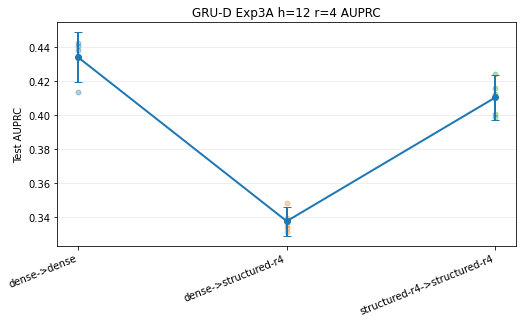

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_grud_exp3a_h12_r4_test_auprc_by_condition_ci95.png


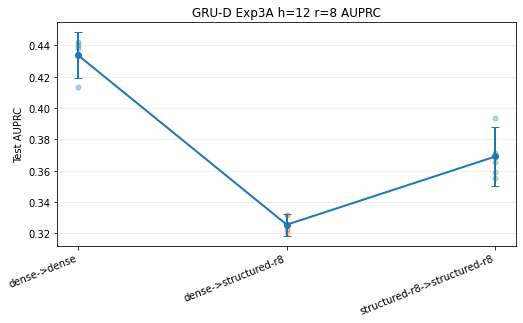

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_grud_exp3a_h12_r8_test_auprc_by_condition_ci95.png


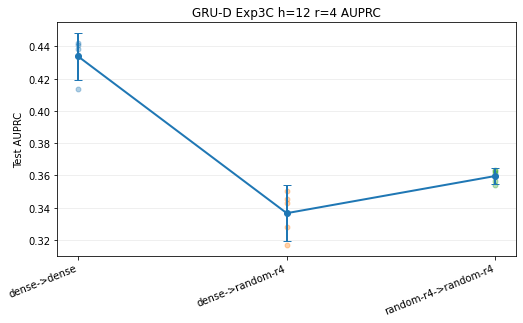

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_grud_exp3c_h12_r4_test_auprc_by_condition_ci95.png


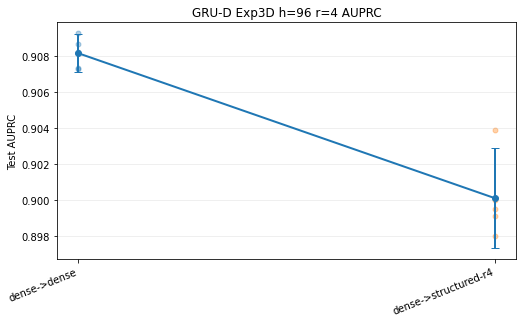

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_grud_exp3d_h96_r4_test_auprc_by_condition_ci95.png


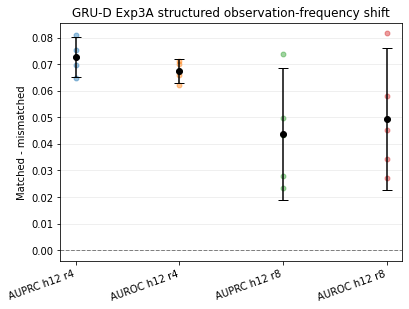

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_grud_exp3a_structured_shift_penalty_ci95.png


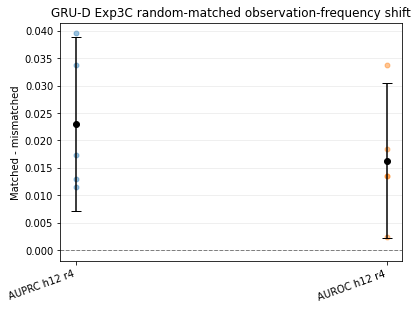

Saved: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_grud_exp3c_random_shift_penalty_ci95.png
Skipping shift plot: no summary rows for GRU-D Exp3D h96 structured observation-frequency shift


In [9]:
def plot_condition_performance(experiment, horizon, r, metric):
    metric_col = "test_{}".format(metric)
    if len(exp3_grud_run_results) == 0 or metric_col not in exp3_grud_run_results.columns:
        return
    sub = exp3_grud_run_results[
        (exp3_grud_run_results["experiment"] == experiment) &
        (exp3_grud_run_results["horizon"].astype(int) == int(horizon)) &
        (exp3_grud_run_results["target_r"].astype(int) == int(r))
    ].copy()
    if len(sub) == 0:
        print("Skipping condition plot: no rows for {} h={} r={} {}".format(experiment, horizon, r, metric))
        return
    summary = summarize_with_t_ci(sub, ["condition"], metric_col)
    order = sub[["condition"]].drop_duplicates()["condition"].tolist()
    summary["order"] = summary["condition"].apply(lambda x: order.index(x) if x in order else 999)
    summary = summary.sort_values("order")
    x = np.arange(len(summary))
    yerr = summary["ci95"].fillna(0.0).values
    plt.figure(figsize=(7.4, 4.6))
    plt.errorbar(x, summary["mean"].values, yerr=yerr, marker="o", capsize=4, linewidth=2)
    for i, condition in enumerate(summary["condition"].tolist()):
        raw = sub[sub["condition"] == condition]
        plt.scatter(np.repeat(i, len(raw)), raw[metric_col].values, alpha=0.35, s=24)
    plt.xticks(x, summary["condition"].tolist(), rotation=22, ha="right")
    plt.ylabel("Test {}".format(metric.upper()))
    plt.title("GRU-D {} h={} r={} {}".format(experiment.split()[0], horizon, r, metric.upper()))
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    safe_experiment = experiment.lower().split()[0]
    output_path = EXP3_GRUD_OUTPUT_DIR / "experiment3_grud_{}_h{}_r{}_test_{}_by_condition_ci95.png".format(
        safe_experiment, horizon, r, metric)
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


def plot_shift_penalty(summary_df, seed_df, title, output_name):
    if summary_df is None or len(summary_df) == 0:
        print("Skipping shift plot: no summary rows for", title)
        return
    sub = summary_df[summary_df["metric"].isin(["auprc", "auroc"])].copy()
    if len(sub) == 0:
        print("Skipping shift plot: no AUPRC/AUROC rows for", title)
        return
    sub["label"] = sub.apply(lambda row: "{} h{} r{}".format(row["metric"].upper(), int(row["horizon"]), int(row["r"])), axis=1)
    x = np.arange(len(sub))
    y = sub["mean_difference"].values
    lo = sub["student_t_ci95_low"].values
    hi = sub["student_t_ci95_high"].values
    yerr = np.nan_to_num(np.vstack([y - lo, hi - y]), nan=0.0)
    plt.figure(figsize=(max(5.8, len(sub) * 1.1), 4.4))
    plt.axhline(0, color="gray", linewidth=1, linestyle="--")
    plt.errorbar(x, y, yerr=yerr, fmt="o", capsize=5, color="black")
    for i, (_, row) in enumerate(sub.iterrows()):
        raw = seed_df[
            (seed_df["metric"] == row["metric"]) &
            (seed_df["horizon"].astype(int) == int(row["horizon"])) &
            (seed_df["r"].astype(int) == int(row["r"]))
        ]
        plt.scatter(np.repeat(i, len(raw)), raw["difference"].values, alpha=0.45, s=24)
    plt.xticks(x, sub["label"].tolist(), rotation=20, ha="right")
    plt.ylabel("Matched - mismatched")
    plt.title(title)
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    output_path = EXP3_GRUD_OUTPUT_DIR / output_name
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


plot_condition_performance("Exp3A Structured frequency shift", 12, 4, "auprc")
plot_condition_performance("Exp3A Structured frequency shift", 12, 8, "auprc")
plot_condition_performance("Exp3C Random-matched frequency shift", 12, 4, "auprc")
plot_condition_performance("Exp3D Horizon replication", 96, 4, "auprc")

plot_shift_penalty(
    exp3_grud_structured_shift_summary,
    exp3_grud_structured_shift_contrasts,
    "GRU-D Exp3A structured observation-frequency shift",
    "experiment3_grud_exp3a_structured_shift_penalty_ci95.png",
)
plot_shift_penalty(
    exp3_grud_random_shift_summary,
    exp3_grud_random_shift_contrasts,
    "GRU-D Exp3C random-matched observation-frequency shift",
    "experiment3_grud_exp3c_random_shift_penalty_ci95.png",
)
plot_shift_penalty(
    exp3_grud_horizon_replication_summary,
    exp3_grud_horizon_replication_contrasts,
    "GRU-D Exp3D h96 structured observation-frequency shift",
    "experiment3_grud_exp3d_h96_shift_penalty_ci95.png",
)

## Cross-Experiment GRU-D Summary

This compact table summarizes the main observation-regime mismatch effects and keeps seed CIs and patient-bootstrap CIs separate.

In [10]:
def format_ci(low, high):
    if pd.isnull(low) or pd.isnull(high):
        return "NA"
    return "[{:.4f}, {:.4f}]".format(float(low), float(high))


main_rows = []
if len(exp3_grud_combined_key_contrast_summary):
    for experiment, horizon, r, contrast in EXP3_GRUD_MAIN_CONTRASTS:
        sub = exp3_grud_combined_key_contrast_summary[
            (exp3_grud_combined_key_contrast_summary["experiment"] == experiment) &
            (exp3_grud_combined_key_contrast_summary["horizon"].astype(int) == int(horizon)) &
            (exp3_grud_combined_key_contrast_summary["r"].astype(int) == int(r)) &
            (exp3_grud_combined_key_contrast_summary["contrast"] == contrast) &
            (exp3_grud_combined_key_contrast_summary["metric"].isin(["auprc", "auroc", "brier"]))
        ]
        for _, row in sub.iterrows():
            main_rows.append({
                "Experiment": experiment,
                "Horizon": int(row["horizon"]),
                "Sampling": row["sampling"],
                "r": int(row["r"]),
                "Metric": row["metric"].upper(),
                "Matched - mismatched": row["mean_difference"],
                "Seed CI": format_ci(row["student_t_ci95_low"], row["student_t_ci95_high"]),
                "Patient bootstrap CI": format_ci(row["patient_bootstrap_ci_low"], row["patient_bootstrap_ci_high"]),
                "n seeds": int(row["n_seeds"]),
                "complete_seed_set": bool(row["complete_seed_set"]),
                "orientation": row["difference_orientation"],
            })
exp3_grud_cross_experiment_summary = pd.DataFrame(main_rows)
show_table("GRU-D cross-experiment mismatch-effect summary", exp3_grud_cross_experiment_summary, max_rows=100)
if len(exp3_grud_cross_experiment_summary):
    exp3_grud_cross_experiment_summary.to_csv(
        EXP3_GRUD_OUTPUT_DIR / "experiment3_grud_cross_experiment_mismatch_summary.csv", index=False)


GRU-D cross-experiment mismatch-effect summary


,Experiment,Horizon,Matched - mismatched,Metric,Patient bootstrap CI,Sampling,Seed CI,complete_seed_set,n seeds,orientation,r
0,Exp3A Structured frequency shift,12,0.072707,AUPRC,"[0.0555, 0.0909]",structured,"[0.0652, 0.0802]",True,5,left - right,4
1,Exp3A Structured frequency shift,12,0.067359,AUROC,"[0.0541, 0.0817]",structured,"[0.0629, 0.0718]",True,5,left - right,4
2,Exp3A Structured frequency shift,12,0.010797,BRIER,"[0.0085, 0.0131]",structured,"[0.0078, 0.0138]",True,5,right Brier - left Brier; positive means left ...,4
3,Exp3A Structured frequency shift,12,0.043580,AUPRC,"[0.0278, 0.0598]",structured,"[0.0187, 0.0685]",True,5,left - right,8
4,Exp3A Structured frequency shift,12,0.049247,AUROC,"[0.0375, 0.0615]",structured,"[0.0225, 0.0760]",True,5,left - right,8
5,Exp3A Structured frequency shift,12,0.007898,BRIER,"[0.0057, 0.0101]",structured,"[0.0028, 0.0130]",True,5,right Brier - left Brier; positive means left ...,8
6,Exp3C Random-matched frequency shift,12,0.023057,AUPRC,"[0.0119, 0.0339]",random-matched-sseed100,"[0.0072, 0.0389]",True,5,left - right,4
7,Exp3C Random-matched frequency shift,12,0.016346,AUROC,"[0.0070, 0.0262]",random-matched-sseed100,"[0.0023, 0.0304]",True,5,left - right,4
8,Exp3C Random-matched frequency shift,12,0.001817,BRIER,"[0.0004, 0.0034]",random-matched-sseed100,"[-0.0004, 0.0040]",True,5,right Brier - left Brier; positive means left ...,4


## Optional LSTM Comparison

The LSTM notebook currently saves plot PNGs and `selected_runs.csv`; it does not save a structured shift-summary CSV in the notebook source. If an LSTM summary exists in memory from running `visualize_exp3_frequency_shift.ipynb` in the same kernel, or if a compatible summary CSV is later added, this section prints a descriptive side-by-side table. Otherwise it skips gracefully.

In [11]:
def lstm_notebook_saved_csvs():
    notebook_path = Path("visualize_exp3_frequency_shift.ipynb") if Path.cwd().name == "visualizers" else Path("visualizers/visualize_exp3_frequency_shift.ipynb")
    if not notebook_path.exists():
        return []
    text = notebook_path.read_text()
    return sorted(set(re.findall(r"to_csv\((?:[^\)]*)['\"]([^'\"]+\.csv)['\"]", text)))


def load_lstm_shift_summary_if_available():
    print("LSTM notebook literal to_csv outputs:", lstm_notebook_saved_csvs() or "<none found>")
    candidate_paths = [
        EXP3_GRUD_OUTPUT_DIR / "experiment3_lstm_combined_key_contrast_summary.csv",
        EXP3_GRUD_OUTPUT_DIR / "experiment3_combined_key_contrast_summary.csv",
    ]
    for candidate in candidate_paths:
        if candidate.exists():
            print("Using saved LSTM summary:", candidate)
            return pd.read_csv(candidate)
    if "exp3_combined_key_contrast_summary" in globals():
        print("Using in-memory LSTM exp3_combined_key_contrast_summary from this kernel.")
        return exp3_combined_key_contrast_summary.copy()
    print("Skipping optional LSTM comparison: no compatible saved or in-memory LSTM shift summary available.")
    return pd.DataFrame()


def side_by_side_lstm_grud(lstm_summary, grud_summary):
    if lstm_summary is None or len(lstm_summary) == 0 or grud_summary is None or len(grud_summary) == 0:
        return pd.DataFrame()
    mapping = [
        ("Exp3A Structured frequency shift", 12, 4, "structured shift", "structured r4, h=12"),
        ("Exp3A Structured frequency shift", 12, 8, "structured shift", "structured r8, h=12"),
        ("Exp3C Random-matched frequency shift", 12, 4, "random-matched shift", "random matched r4, h=12"),
        ("Exp3D Horizon replication", 96, 4, "structured shift", "structured r4, h=96"),
    ]
    rows = []
    for experiment, horizon, r, contrast, label in mapping:
        for metric in ["auprc", "auroc", "brier"]:
            lstm = lstm_summary[
                (lstm_summary["experiment"] == experiment) &
                (lstm_summary["horizon"].astype(int) == int(horizon)) &
                (lstm_summary["r"].astype(int) == int(r)) &
                (lstm_summary["contrast"] == contrast) &
                (lstm_summary["metric"] == metric)
            ] if set(["experiment", "horizon", "r", "contrast", "metric"]).issubset(lstm_summary.columns) else pd.DataFrame()
            grud = grud_summary[
                (grud_summary["experiment"] == experiment) &
                (grud_summary["horizon"].astype(int) == int(horizon)) &
                (grud_summary["r"].astype(int) == int(r)) &
                (grud_summary["contrast"] == contrast) &
                (grud_summary["metric"] == metric)
            ]
            if len(lstm) == 0 and len(grud) == 0:
                continue
            lstm_row = lstm.iloc[0] if len(lstm) else pd.Series(dtype=float)
            grud_row = grud.iloc[0] if len(grud) else pd.Series(dtype=float)
            rows.append({
                "Experiment": label,
                "Metric": metric.upper(),
                "LSTM shift": lstm_row.get("mean_difference", np.nan),
                "LSTM seed CI": format_ci(lstm_row.get("student_t_ci95_low", np.nan), lstm_row.get("student_t_ci95_high", np.nan)),
                "GRU-D shift": grud_row.get("mean_difference", np.nan),
                "GRU-D seed CI": format_ci(grud_row.get("student_t_ci95_low", np.nan), grud_row.get("student_t_ci95_high", np.nan)),
                "GRU-D n seeds": grud_row.get("n_seeds", np.nan),
            })
    return pd.DataFrame(rows)


lstm_summary = load_lstm_shift_summary_if_available()
model_comparison_table = side_by_side_lstm_grud(lstm_summary, exp3_grud_combined_key_contrast_summary)
show_table("Optional LSTM vs GRU-D shift comparison", model_comparison_table, max_rows=100)
print("Interpretation guardrail: this table is descriptive only; do not claim relative robustness without the actual intervals/results supporting it.")

LSTM notebook literal to_csv outputs: <none found>
Using saved LSTM summary: /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_lstm_combined_key_contrast_summary.csv

Optional LSTM vs GRU-D shift comparison


,Experiment,GRU-D n seeds,GRU-D seed CI,GRU-D shift,LSTM seed CI,LSTM shift,Metric
0,"structured r4, h=12",5.0,"[0.0652, 0.0802]",0.072707,NA,0.078936,AUPRC
1,"structured r4, h=12",5.0,"[0.0629, 0.0718]",0.067359,NA,0.056864,AUROC
2,"structured r4, h=12",5.0,"[0.0078, 0.0138]",0.010797,NA,0.015694,BRIER
3,"structured r8, h=12",5.0,"[0.0187, 0.0685]",0.043580,NA,0.078472,AUPRC
4,"structured r8, h=12",5.0,"[0.0225, 0.0760]",0.049247,NA,0.068012,AUROC
5,"structured r8, h=12",5.0,"[0.0028, 0.0130]",0.007898,NA,0.017375,BRIER
6,"random matched r4, h=12",5.0,"[0.0072, 0.0389]",0.023057,NA,0.028058,AUPRC
7,"random matched r4, h=12",5.0,"[0.0023, 0.0304]",0.016346,NA,0.019363,AUROC
8,"random matched r4, h=12",5.0,"[-0.0004, 0.0040]",0.001817,NA,0.005186,BRIER
9,"structured r4, h=96",NaN,NA,NaN,NA,0.010324,AUPRC


Interpretation guardrail: this table is descriptive only; do not claim relative robustness without the actual intervals/results supporting it.


## Final Status Summary

In [12]:
def condition_seed_status(experiment, horizon, r, contrast_family):
    if len(exp3_grud_run_results) == 0:
        observed = set()
    else:
        sub = exp3_grud_run_results[
            (exp3_grud_run_results["experiment"] == experiment) &
            (exp3_grud_run_results["horizon"].astype(int) == int(horizon)) &
            (exp3_grud_run_results["target_r"].astype(int) == int(r)) &
            (exp3_grud_run_results["contrast_family"] == contrast_family)
        ]
        by_condition = [set(g["model_seed"].astype(int).tolist()) for _, g in sub.groupby("condition")]
        observed = set.intersection(*by_condition) if by_condition else set()
    return {
        "observed_seeds": sorted(observed),
        "missing_seeds": sorted(EXP3_GRUD_EXPECTED_MODEL_SEEDS - observed),
        "n_seeds": len(observed),
        "complete_seed_set": observed == EXP3_GRUD_EXPECTED_MODEL_SEEDS,
    }


status_specs = [
    ("Exp3A r4", "Exp3A Structured frequency shift", 12, 4, "structured_shift"),
    ("Exp3A r8", "Exp3A Structured frequency shift", 12, 8, "structured_shift"),
    ("Exp3B", "Exp3B Normalizer control", 12, 4, "normalizer_control"),
    ("Exp3C", "Exp3C Random-matched frequency shift", 12, 4, "random_shift"),
    ("Exp3D", "Exp3D Horizon replication", 96, 4, "horizon_replication"),
]
status_rows = []
for label, experiment, horizon, r, family in status_specs:
    row = {"sub_experiment": label, "experiment": experiment, "horizon": horizon, "r": r}
    row.update(condition_seed_status(experiment, horizon, r, family))
    status_rows.append(row)
exp3_grud_final_status = pd.DataFrame(status_rows)
show_table("GRU-D Exp3 final status", exp3_grud_final_status, max_rows=20)

if len(exp3_grud_run_status):
    action_counts = exp3_grud_run_status["prediction_action"].value_counts(dropna=False).rename_axis("prediction_action").reset_index(name="n")
else:
    action_counts = pd.DataFrame(columns=["prediction_action", "n"])
show_table("GRU-D prediction-file actions", action_counts, max_rows=20)

reused_predictions = exp3_grud_run_status[exp3_grud_run_status.get("prediction_action") == "reused"] if len(exp3_grud_run_status) else pd.DataFrame()
generated_predictions = exp3_grud_run_status[exp3_grud_run_status.get("prediction_action").isin(["generated", "regenerated"])] if len(exp3_grud_run_status) else pd.DataFrame()
failed_predictions = exp3_grud_run_status[exp3_grud_run_status.get("prediction_action") == "failed"] if len(exp3_grud_run_status) else pd.DataFrame()
show_table("Reused GRU-D prediction files", reused_predictions[[c for c in ["experiment", "condition", "horizon", "target_r", "model_seed", "prediction_path"] if c in reused_predictions.columns]], max_rows=200)
show_table("Generated/regenerated GRU-D prediction files", generated_predictions[[c for c in ["experiment", "condition", "horizon", "target_r", "model_seed", "prediction_path"] if c in generated_predictions.columns]], max_rows=200)
show_table("Failed GRU-D prediction generations", failed_predictions[[c for c in ["experiment", "condition", "horizon", "target_r", "model_seed", "expected_prediction_path", "missing_reason"] if c in failed_predictions.columns]], max_rows=200)

if len(exp3_grud_train_status):
    incomplete_runs = exp3_grud_train_status[exp3_grud_train_status["complete"] == False]
else:
    incomplete_runs = pd.DataFrame()
show_table("Incomplete GRU-D training runs", incomplete_runs[[c for c in ["run_kind", "horizon", "source_r", "model_seed", "n_epochs", "log_path"] if c in incomplete_runs.columns]], max_rows=200)

final_coverage_rows = []
for experiment, horizon, r, contrast in EXP3_GRUD_MAIN_CONTRASTS + [("Exp3B Normalizer control", 12, 4, "normalizer control")]:
    for metric in EXP3_GRUD_METRICS:
        sub = exp3_grud_combined_key_contrast_summary[
            (exp3_grud_combined_key_contrast_summary["experiment"] == experiment) &
            (exp3_grud_combined_key_contrast_summary["horizon"].astype(int) == int(horizon)) &
            (exp3_grud_combined_key_contrast_summary["r"].astype(int) == int(r)) &
            (exp3_grud_combined_key_contrast_summary["contrast"] == contrast) &
            (exp3_grud_combined_key_contrast_summary["metric"] == metric)
        ] if len(exp3_grud_combined_key_contrast_summary) else pd.DataFrame()
        final_coverage_rows.append({
            "experiment": experiment,
            "horizon": horizon,
            "r": r,
            "contrast": contrast,
            "metric": metric,
            "present": len(sub) == 1,
            "n_seeds": int(sub.iloc[0]["n_seeds"]) if len(sub) == 1 else 0,
            "complete_seed_set": bool(sub.iloc[0]["complete_seed_set"]) if len(sub) == 1 else False,
            "final_reporting_ready": bool(len(sub) == 1 and sub.iloc[0]["complete_seed_set"]),
        })
exp3_grud_final_contrast_coverage = pd.DataFrame(final_coverage_rows)
show_table("GRU-D final contrast coverage", exp3_grud_final_contrast_coverage, max_rows=100)


GRU-D Exp3 final status


,complete_seed_set,experiment,horizon,missing_seeds,n_seeds,observed_seeds,r,sub_experiment
0,True,Exp3A Structured frequency shift,12,[],5,"[0, 1, 2, 3, 4]",4,Exp3A r4
1,True,Exp3A Structured frequency shift,12,[],5,"[0, 1, 2, 3, 4]",8,Exp3A r8
2,False,Exp3B Normalizer control,12,"[1, 2, 4]",2,"[0, 3]",4,Exp3B
3,True,Exp3C Random-matched frequency shift,12,[],5,"[0, 1, 2, 3, 4]",4,Exp3C
4,True,Exp3D Horizon replication,96,[],5,"[0, 1, 2, 3, 4]",4,Exp3D



GRU-D prediction-file actions


,prediction_action,n
0,reused,44
1,generated,18



Reused GRU-D prediction files


...

,experiment,condition,horizon,target_r,model_seed,prediction_path
11,Exp3A Structured frequency shift,structured-r4->structured-r4,12,4,1,/heinz-georgenas/users/mingzhul/Simultaneous-E...
12,Exp3A Structured frequency shift,structured-r4->structured-r4,12,4,2,/heinz-georgenas/users/mingzhul/Simultaneous-E...
13,Exp3A Structured frequency shift,structured-r4->structured-r4,12,4,3,/heinz-georgenas/users/mingzhul/Simultaneous-E...
14,Exp3A Structured frequency shift,structured-r4->structured-r4,12,4,4,/heinz-georgenas/users/mingzhul/Simultaneous-E...
28,Exp3A Structured frequency shift,structured-r8->structured-r8,12,8,3,/heinz-georgenas/users/mingzhul/Simultaneous-E...
29,Exp3A Structured frequency shift,structured-r8->structured-r8,12,8,4,/heinz-georgenas/users/mingzhul/Simultaneous-E...
30,Exp3B Normalizer control,structured-r4 train + dense norm,12,4,0,/heinz-georgenas/users/mingzhul/Simultaneous-E...
31,Exp3B Normalizer control,structured-r4 train + dense norm,12,4,3,/heinz-georgenas/users/mingzhul/Simultaneous-E...
48,Exp3C Random-matched frequency shift,random-r4->random-r4,12,4,1,/heinz-georgenas/users/mingzhul/Simultaneous-E...
49,Exp3C Random-matched frequency shift,random-r4->random-r4,12,4,2,/heinz-georgenas/users/mingzhul/Simultaneous-E...



Failed GRU-D prediction generations
<none>

Incomplete GRU-D training runs


,run_kind,horizon,source_r,model_seed,n_epochs,log_path
25,normalizer_control_dense,12,4.0,0,3,/heinz-georgenas/users/mingzhul/Simultaneous-E...
26,normalizer_control_dense,12,4.0,3,2,/heinz-georgenas/users/mingzhul/Simultaneous-E...



GRU-D final contrast coverage


,complete_seed_set,contrast,experiment,final_reporting_ready,horizon,metric,n_seeds,present,r
0,True,structured shift,Exp3A Structured frequency shift,True,12,auprc,5,True,4
1,True,structured shift,Exp3A Structured frequency shift,True,12,auroc,5,True,4
2,True,structured shift,Exp3A Structured frequency shift,True,12,brier,5,True,4
3,True,structured shift,Exp3A Structured frequency shift,True,12,auprc,5,True,8
4,True,structured shift,Exp3A Structured frequency shift,True,12,auroc,5,True,8
5,True,structured shift,Exp3A Structured frequency shift,True,12,brier,5,True,8
6,True,random-matched shift,Exp3C Random-matched frequency shift,True,12,auprc,5,True,4
7,True,random-matched shift,Exp3C Random-matched frequency shift,True,12,auroc,5,True,4
8,True,random-matched shift,Exp3C Random-matched frequency shift,True,12,brier,5,True,4
9,False,structured shift,Exp3D Horizon replication,False,96,auprc,0,False,4


## Definitions Recap

- Exp3A: h=12 structured frequency shift for r=4 and r=8. Contrasts compare `structured-r -> structured-r` against `dense -> structured-r`.
- Exp3B: h=12 structured r=4 normalizer control. Contrasts compare the standard structured-r4 train-matched normalizer condition against the `structured_r4_dense_norm_control` dense-normalizer condition.
- Exp3C: h=12 random matched-count r=4 with sampling seed 100. Contrasts compare `random-r4 -> random-r4` against `dense -> random-r4`; seed 100 is included in discovery, inference, prediction identity, and filenames.
- Exp3D: h=96 structured r=4 replication. Contrasts compare `structured-r4 -> structured-r4` against `dense -> structured-r4`.
- Checkpoint selection always uses validation AUPRC, never test metrics.
- Normalizers are selected from the training regime, except the deliberate Exp3B dense-normalizer override copied from the LSTM notebook.

## Stable summary CSV exports

These exports are consumed by `visualize_summary.ipynb`. They only save dataframes already computed by this source notebook; they do not perform discovery, inference, or checkpoint selection.


In [13]:
# SUMMARY_EXPORTS_EXP3_GRUD
SUMMARY_EXPORTS_EXP3_GRUD = {
    "exp3_grud_train_status": "experiment3_grud_train_status.csv",
    "exp3_grud_train_excluded": "experiment3_grud_train_excluded.csv",
    "exp3_grud_run_status": "experiment3_grud_run_status.csv",
    "exp3_grud_missing": "experiment3_grud_missing_predictions.csv",
    "exp3_grud_run_results": "experiment3_grud_condition_run_results.csv",
    "exp3_grud_condition_seed_status": "experiment3_grud_condition_seed_status.csv",
    "exp3_grud_across_seed_summary": "experiment3_grud_across_seed_summary.csv",
    "exp3_grud_structured_shift_contrasts": "experiment3_grud_structured_shift_seed_level.csv",
    "exp3_grud_structured_shift_summary": "experiment3_grud_structured_shift_summary.csv",
    "exp3_grud_normalizer_control_contrasts": "experiment3_grud_normalizer_control_seed_level.csv",
    "exp3_grud_normalizer_control_summary": "experiment3_grud_normalizer_control_summary.csv",
    "exp3_grud_random_shift_contrasts": "experiment3_grud_random_shift_seed_level.csv",
    "exp3_grud_random_shift_summary": "experiment3_grud_random_shift_summary.csv",
    "exp3_grud_horizon_replication_contrasts": "experiment3_grud_horizon_replication_seed_level.csv",
    "exp3_grud_horizon_replication_summary": "experiment3_grud_horizon_replication_summary.csv",
    "exp3_grud_combined_key_contrast_summary": "experiment3_grud_combined_key_contrast_summary.csv",
    "exp3_grud_cross_experiment_summary": "experiment3_grud_cross_experiment_mismatch_summary.csv",
    "exp3_grud_final_status": "experiment3_grud_final_status.csv",
    "exp3_grud_final_contrast_coverage": "experiment3_grud_final_contrast_coverage.csv",
}
for _name, _filename in SUMMARY_EXPORTS_EXP3_GRUD.items():
    _obj = globals().get(_name)
    if isinstance(_obj, pd.DataFrame):
        _path = EXP3_GRUD_OUTPUT_DIR / _filename
        _obj.to_csv(_path, index=False)
        print("exported", _name, "->", _path)
    else:
        print("skipped", _name, "not available")


exported exp3_grud_train_status -> /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_grud_train_status.csv
exported exp3_grud_train_excluded -> /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_grud_train_excluded.csv
exported exp3_grud_run_status -> /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_grud_run_status.csv
exported exp3_grud_missing -> /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_grud_missing_predictions.csv
exported exp3_grud_run_results -> /heinz-georgenas/users/mingzhul/Simultaneous-EHR/data/physionet.org/files/mimiciv/1.0/russo/results/fixed_horizon_icu_exit/plots/experiment3_grud_condition_run_results.csv
